# 서울시 공공자전거 대여소 공간 군집화 분석

## 분석 목적

본 노트북에서는 전처리가 완료된 서울시 공공자전거 대여소의 위도·경도 정보를 이용하여 공간 군집을 구축한다.

대여소 단위 수요를 직접 예측하면 대여소 수가 많고 개별 대여소의 시간대별 결측 조합이 증가하여 모델링 복잡도가 커진다. 이에 지리적으로 가까운 대여소를 동일한 권역으로 묶고, 권역별 시간당 이용건수를 생성하여 후속 수요예측 모델의 분석 단위로 사용한다.

주요 분석 과정은 다음과 같다.

1. 분석용 대여소 마스터와 월별 시간대 수요 파일을 불러온다.
2. 위도·경도 분포와 자치구별 대여소 현황을 점검한다.
3. K-Means 군집 수 후보를 Silhouette Score와 군집 규모를 이용해 비교한다.
4. 최종 공간 군집을 확정하고 대여소별 군집 번호를 저장한다.
5. 월별 대여소 수요를 군집·시간 단위로 집계한다.
6. 전체 수요가 군집 집계 전후에 보존되는지 검증한다.

본 분석에서는 전처리 단계에서 확정한 실제 대여소번호 기반 마스터와 공간 분석용 월별 수요 파일만 사용한다.

## 1. 분석 환경 및 경로 설정

공간 군집화 분석에 필요한 라이브러리를 불러오고 프로젝트 루트와 입력·출력 경로를 설정한다.

전처리 단계에서 생성한 다음 산출물의 존재 여부를 확인한다.

- 실제 대여소번호 기반 분석용 대여소 마스터
- 공간 분석용 월별 시간대 수요 파일
- 전처리 최종 요약 파일
- 전처리 최종 검증 파일

또한 공간 분석 결과를 저장할 `outputs/figures`, `outputs/metrics`, `outputs/reports` 폴더를 생성한다.

In [1]:
from pathlib import Path
import gc
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings("ignore")


# 프로젝트 루트를 탐색한다.
current_path = Path.cwd().resolve()

root_candidates = [
    current_path,
    current_path.parent,
    current_path.parent.parent,
]


ROOT = None


for candidate in root_candidates:
    if (
        (candidate / "data").exists()
        and (candidate / "notebooks").exists()
    ):
        ROOT = candidate
        break


if ROOT is None:
    raise FileNotFoundError(
        "프로젝트 루트를 찾지 못했다. "
        "notebooks 폴더에서 노트북을 실행해야 한다."
    )


PROCESSED_DIR = (
    ROOT / "data" / "processed"
)

STATION_MASTER_PATH = (
    PROCESSED_DIR
    / "station_master_clean.csv"
)

SPATIAL_MONTHLY_DIR = (
    PROCESSED_DIR
    / "station_hourly_spatial_monthly"
)

PREPROCESSING_SUMMARY_PATH = (
    PROCESSED_DIR
    / "preprocessing_final_summary.csv"
)

PREPROCESSING_VALIDATION_PATH = (
    PROCESSED_DIR
    / "preprocessing_final_validation.csv"
)


OUTPUTS_DIR = (
    ROOT / "outputs"
)

FIGURES_DIR = (
    OUTPUTS_DIR / "figures"
)

METRICS_DIR = (
    OUTPUTS_DIR / "metrics"
)

REPORTS_DIR = (
    OUTPUTS_DIR / "reports"
)


for directory in [
    OUTPUTS_DIR,
    FIGURES_DIR,
    METRICS_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


required_paths = {
    "분석용 대여소 마스터": (
        STATION_MASTER_PATH
    ),
    "공간 분석용 월별 수요 폴더": (
        SPATIAL_MONTHLY_DIR
    ),
    "전처리 최종 요약": (
        PREPROCESSING_SUMMARY_PATH
    ),
    "전처리 최종 검증": (
        PREPROCESSING_VALIDATION_PATH
    ),
}


missing_paths = [
    name
    for name, path in required_paths.items()
    if not path.exists()
]


if missing_paths:
    raise FileNotFoundError(
        "필수 전처리 산출물이 존재하지 않는다: "
        f"{missing_paths}"
    )


spatial_monthly_files = sorted(
    SPATIAL_MONTHLY_DIR.glob(
        "station_hourly_*.csv"
    )
)


if len(spatial_monthly_files) != 24:
    raise ValueError(
        "공간 분석용 월별 파일이 "
        f"24개가 아니다: "
        f"{len(spatial_monthly_files)}개"
    )


print("[프로젝트 경로]")
print(f"ROOT: {ROOT}")
print(
    "전처리 데이터: "
    f"{PROCESSED_DIR.relative_to(ROOT)}"
)
print(
    "분석 결과 폴더: "
    f"{OUTPUTS_DIR.relative_to(ROOT)}"
)


print("\n[필수 입력 파일]")
for name, path in required_paths.items():
    print(
        f"- {name}: "
        f"{path.relative_to(ROOT)}"
    )


print("\n[공간 분석용 월별 파일]")
print(
    f"파일 수: "
    f"{len(spatial_monthly_files)}개"
)
print(
    f"첫 파일: "
    f"{spatial_monthly_files[0].name}"
)
print(
    f"마지막 파일: "
    f"{spatial_monthly_files[-1].name}"
)

[프로젝트 경로]
ROOT: C:\Users\user\Desktop\주진호\05.ICT 인턴십\02.공공자전거
전처리 데이터: data\processed
분석 결과 폴더: outputs

[필수 입력 파일]
- 분석용 대여소 마스터: data\processed\station_master_clean.csv
- 공간 분석용 월별 수요 폴더: data\processed\station_hourly_spatial_monthly
- 전처리 최종 요약: data\processed\preprocessing_final_summary.csv
- 전처리 최종 검증: data\processed\preprocessing_final_validation.csv

[공간 분석용 월별 파일]
파일 수: 24개
첫 파일: station_hourly_202301.csv
마지막 파일: station_hourly_202412.csv


## 2. 분석 입력 데이터 로드 및 기본 검증

공간 군집화에 사용할 대여소 마스터와 전처리 품질 보고서를 불러온다.

분석 시작 전에 다음 조건을 확인한다.

- 전처리 최종 검증 항목이 모두 통과했는지 확인한다.
- 분석용 대여소가 2,847개인지 확인한다.
- 대여소번호가 중복되지 않는지 확인한다.
- 위도와 경도에 결측치가 없는지 확인한다.
- 모든 좌표가 서울시 분석 범위 안에 있는지 확인한다.
- 공간 분석용 월별 파일이 2023년 1월부터 2024년 12월까지 24개인지 확인한다.
- 월별 수요 데이터의 전체 행 수와 이용건수가 전처리 결과와 일치하는지 확인한다.

검증을 통과한 대여소 마스터를 이후 K-Means 공간 군집화의 입력 데이터로 사용한다.

In [2]:
# 1. 추가 입력 파일 경로를 설정한다.

SPATIAL_QUALITY_PATH = (
    PROCESSED_DIR
    / "spatial_demand_quality_by_month.csv"
)


if not SPATIAL_QUALITY_PATH.exists():
    raise FileNotFoundError(
        "공간 분석 월별 품질 파일이 존재하지 않는다: "
        f"{SPATIAL_QUALITY_PATH.relative_to(ROOT)}"
    )


# 2. 전처리 최종 검증 결과를 불러온다.

preprocessing_validation = pd.read_csv(
    PREPROCESSING_VALIDATION_PATH,
    encoding="utf-8-sig",
)


required_validation_columns = {
    "validation_item",
    "status",
    "passed",
    "actual",
    "expected",
}


missing_validation_columns = sorted(
    required_validation_columns
    - set(preprocessing_validation.columns)
)


if missing_validation_columns:
    raise KeyError(
        "전처리 최종 검증 파일에 필수 컬럼이 없다: "
        f"{missing_validation_columns}"
    )


validation_status = (
    preprocessing_validation[
        "status"
    ]
    .astype("string")
    .str.strip()
    .str.upper()
)


failed_preprocessing_validation = (
    preprocessing_validation.loc[
        validation_status.ne("PASS")
    ]
    .copy()
    .reset_index(drop=True)
)


all_preprocessing_validation_passed = (
    failed_preprocessing_validation.empty
)


print("[전처리 검증 확인]")
print(
    f"전체 검증 항목: "
    f"{len(preprocessing_validation):,}개"
)
print(
    f"통과 항목: "
    f"{validation_status.eq('PASS').sum():,}개"
)
print(
    f"실패 항목: "
    f"{len(failed_preprocessing_validation):,}개"
)
print(
    "전처리 최종 상태: "
    f"{'PASS' if all_preprocessing_validation_passed else 'FAIL'}"
)


if not all_preprocessing_validation_passed:
    print("\n[전처리 실패 항목]")
    display(
        failed_preprocessing_validation
    )

    raise ValueError(
        "전처리 최종 검증에 실패한 항목이 있으므로 "
        "공간 군집화를 진행할 수 없다."
    )


# 3. 전처리 최종 요약을 불러온다.

preprocessing_summary = pd.read_csv(
    PREPROCESSING_SUMMARY_PATH,
    encoding="utf-8-sig",
    dtype="string",
)


required_summary_columns = {
    "summary_item",
    "value",
}


missing_summary_columns = sorted(
    required_summary_columns
    - set(preprocessing_summary.columns)
)


if missing_summary_columns:
    raise KeyError(
        "전처리 최종 요약 파일에 필수 컬럼이 없다: "
        f"{missing_summary_columns}"
    )


preprocessing_summary_dict = dict(
    zip(
        preprocessing_summary[
            "summary_item"
        ],
        preprocessing_summary[
            "value"
        ],
    )
)


final_preprocessing_result = (
    preprocessing_summary_dict.get(
        "최종 검증 결과"
    )
)


if final_preprocessing_result != "PASS":
    raise ValueError(
        "전처리 최종 요약의 검증 결과가 "
        f"PASS가 아니다: {final_preprocessing_result}"
    )


# 4. 분석용 대여소 마스터를 불러온다.

station_master = pd.read_csv(
    STATION_MASTER_PATH,
    encoding="utf-8-sig",
    dtype={
        "station_id": "string",
        "station_name": "string",
        "district": "string",
        "address": "string",
        "raw_station_ids": "string",
    },
    parse_dates=[
        "installation_date",
        "snapshot_date",
    ],
)


required_station_columns = {
    "station_id",
    "station_name",
    "district",
    "latitude",
    "longitude",
    "meaningful_coordinate_movement",
    "rental_count",
}


missing_station_columns = sorted(
    required_station_columns
    - set(station_master.columns)
)


if missing_station_columns:
    raise KeyError(
        "분석용 대여소 마스터에 필수 컬럼이 없다: "
        f"{missing_station_columns}"
    )


station_master[
    "station_id"
] = (
    station_master[
        "station_id"
    ]
    .astype("string")
    .str.strip()
)


station_master[
    "latitude"
] = pd.to_numeric(
    station_master[
        "latitude"
    ],
    errors="coerce",
)


station_master[
    "longitude"
] = pd.to_numeric(
    station_master[
        "longitude"
    ],
    errors="coerce",
)


station_master[
    "rental_count"
] = pd.to_numeric(
    station_master[
        "rental_count"
    ],
    errors="coerce",
)


# CSV에서 불러온 불리언 값을 안전하게 변환한다.
if pd.api.types.is_bool_dtype(
    station_master[
        "meaningful_coordinate_movement"
    ]
):
    station_master[
        "meaningful_coordinate_movement"
    ] = (
        station_master[
            "meaningful_coordinate_movement"
        ]
        .fillna(False)
        .astype(bool)
    )

else:
    station_master[
        "meaningful_coordinate_movement"
    ] = (
        station_master[
            "meaningful_coordinate_movement"
        ]
        .astype("string")
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
        .fillna(False)
        .astype(bool)
    )


station_master = (
    station_master
    .sort_values(
        "station_id"
    )
    .reset_index(drop=True)
)


# 5. 대여소 마스터의 기본 품질을 검증한다.

EXPECTED_STATION_COUNT = 2_847
EXPECTED_DISTRICT_COUNT = 25
EXPECTED_MEANINGFUL_MOVEMENT_COUNT = 38
EXPECTED_SPATIAL_ROW_COUNT = 26_127_479
EXPECTED_SPATIAL_RENTAL_COUNT = 88_708_877


station_duplicate_count = int(
    station_master[
        "station_id"
    ]
    .duplicated()
    .sum()
)


station_core_missing_count = int(
    station_master[
        [
            "station_id",
            "station_name",
            "district",
            "latitude",
            "longitude",
        ]
    ]
    .isna()
    .sum()
    .sum()
)


valid_latitude = (
    station_master[
        "latitude"
    ]
    .between(
        37.4,
        37.8,
    )
    .fillna(False)
)


valid_longitude = (
    station_master[
        "longitude"
    ]
    .between(
        126.7,
        127.3,
    )
    .fillna(False)
)


valid_gps = (
    valid_latitude
    & valid_longitude
)


meaningful_movement_count = int(
    station_master[
        "meaningful_coordinate_movement"
    ].sum()
)


district_count = int(
    station_master[
        "district"
    ].nunique()
)


if len(station_master) != EXPECTED_STATION_COUNT:
    raise ValueError(
        "분석용 대여소 수가 예상값과 다르다: "
        f"{len(station_master):,}개"
    )


if station_duplicate_count != 0:
    raise ValueError(
        "분석용 대여소번호에 중복이 존재한다: "
        f"{station_duplicate_count:,}개"
    )


if station_core_missing_count != 0:
    raise ValueError(
        "분석용 대여소 마스터의 핵심 변수에 "
        f"결측치가 존재한다: {station_core_missing_count:,}개"
    )


if not valid_gps.all():
    raise ValueError(
        "서울시 분석 범위를 벗어난 GPS가 존재한다: "
        f"{(~valid_gps).sum():,}개"
    )


if district_count != EXPECTED_DISTRICT_COUNT:
    raise ValueError(
        "자치구 수가 예상값 25개와 다르다: "
        f"{district_count:,}개"
    )


if (
    meaningful_movement_count
    != EXPECTED_MEANINGFUL_MOVEMENT_COUNT
):
    raise ValueError(
        "10m 이상 좌표 이동 대여소 수가 "
        "예상값과 다르다: "
        f"{meaningful_movement_count:,}개"
    )


print("\n[분석용 대여소 마스터 구조]")
print(
    f"행 수: "
    f"{len(station_master):,}개"
)
print(
    f"컬럼 수: "
    f"{station_master.shape[1]:,}개"
)
print(
    f"고유 대여소번호: "
    f"{station_master['station_id'].nunique():,}개"
)
print(
    f"자치구 수: "
    f"{district_count:,}개"
)
print(
    f"핵심 변수 결측: "
    f"{station_core_missing_count:,}개"
)
print(
    f"유효 GPS 대여소: "
    f"{valid_gps.sum():,}개"
)
print(
    f"10m 이상 좌표 이동 대여소: "
    f"{meaningful_movement_count:,}개"
)


print("\n[GPS 범위]")
print(
    "위도: "
    f"{station_master['latitude'].min():.6f}"
    " ~ "
    f"{station_master['latitude'].max():.6f}"
)
print(
    "경도: "
    f"{station_master['longitude'].min():.6f}"
    " ~ "
    f"{station_master['longitude'].max():.6f}"
)


# 6. 공간 분석 월별 품질 정보를 불러온다.

spatial_demand_quality = pd.read_csv(
    SPATIAL_QUALITY_PATH,
    encoding="utf-8-sig",
    dtype={
        "year_month": "string",
    },
)


required_quality_columns = {
    "year_month",
    "spatial_row_count",
    "spatial_station_count",
    "spatial_rental_count",
    "spatial_rental_share_pct",
}


missing_quality_columns = sorted(
    required_quality_columns
    - set(spatial_demand_quality.columns)
)


if missing_quality_columns:
    raise KeyError(
        "공간 분석 월별 품질 파일에 필수 컬럼이 없다: "
        f"{missing_quality_columns}"
    )


numeric_quality_columns = [
    "spatial_row_count",
    "spatial_station_count",
    "spatial_rental_count",
    "spatial_rental_share_pct",
]


for column in numeric_quality_columns:
    spatial_demand_quality[
        column
    ] = pd.to_numeric(
        spatial_demand_quality[
            column
        ],
        errors="coerce",
    )


spatial_demand_quality = (
    spatial_demand_quality
    .sort_values(
        "year_month"
    )
    .reset_index(drop=True)
)


total_spatial_rows = int(
    spatial_demand_quality[
        "spatial_row_count"
    ].sum()
)


total_spatial_rental_count = int(
    spatial_demand_quality[
        "spatial_rental_count"
    ].sum()
)


if len(spatial_demand_quality) != 24:
    raise ValueError(
        "공간 분석 월별 품질 기록이 "
        f"24개월이 아니다: {len(spatial_demand_quality)}개월"
    )


if (
    total_spatial_rows
    != EXPECTED_SPATIAL_ROW_COUNT
):
    raise ValueError(
        "공간 분석 전체 행 수가 예상값과 다르다: "
        f"{total_spatial_rows:,}행"
    )


if (
    total_spatial_rental_count
    != EXPECTED_SPATIAL_RENTAL_COUNT
):
    raise ValueError(
        "공간 분석 전체 이용건수가 예상값과 다르다: "
        f"{total_spatial_rental_count:,}건"
    )


print("\n[공간 수요 메타데이터]")
print(
    f"분석 월 수: "
    f"{len(spatial_demand_quality):,}개월"
)
print(
    f"첫 분석월: "
    f"{spatial_demand_quality['year_month'].min()}"
)
print(
    f"마지막 분석월: "
    f"{spatial_demand_quality['year_month'].max()}"
)
print(
    f"전체 행 수: "
    f"{total_spatial_rows:,}행"
)
print(
    f"전체 이용건수: "
    f"{total_spatial_rental_count:,}건"
)
print(
    "최소 월별 수요 커버리지: "
    f"{spatial_demand_quality['spatial_rental_share_pct'].min():.6f}%"
)


# 7. 자치구별 대여소 현황을 요약한다.

district_station_summary = (
    station_master
    .groupby(
        "district",
        as_index=False,
    )
    .agg(
        station_count=(
            "station_id",
            "nunique",
        ),
        total_rental_count=(
            "rental_count",
            "sum",
        ),
        latitude_mean=(
            "latitude",
            "mean",
        ),
        longitude_mean=(
            "longitude",
            "mean",
        ),
    )
)


district_station_summary[
    "station_share_pct"
] = (
    district_station_summary[
        "station_count"
    ]
    .div(
        district_station_summary[
            "station_count"
        ].sum()
    )
    .mul(100)
)


district_station_summary[
    "rental_share_pct"
] = (
    district_station_summary[
        "total_rental_count"
    ]
    .div(
        district_station_summary[
            "total_rental_count"
        ].sum()
    )
    .mul(100)
)


district_station_summary = (
    district_station_summary
    .sort_values(
        [
            "station_count",
            "total_rental_count",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


print("\n[자치구별 대여소 현황]")
display(
    district_station_summary
)


print("\n[분석용 대여소 마스터 표본]")
display(
    station_master[
        [
            "station_id",
            "station_name",
            "district",
            "latitude",
            "longitude",
            "rental_count",
            "meaningful_coordinate_movement",
        ]
    ].head(10)
)

[전처리 검증 확인]
전체 검증 항목: 52개
통과 항목: 52개
실패 항목: 0개
전처리 최종 상태: PASS

[분석용 대여소 마스터 구조]
행 수: 2,847개
컬럼 수: 27개
고유 대여소번호: 2,847개
자치구 수: 25개
핵심 변수 결측: 0개
유효 GPS 대여소: 2,847개
10m 이상 좌표 이동 대여소: 38개

[GPS 범위]
위도: 37.430977 ~ 37.691013
경도: 126.798599 ~ 127.180756

[공간 수요 메타데이터]
분석 월 수: 24개월
첫 분석월: 202301
마지막 분석월: 202412
전체 행 수: 26,127,479행
전체 이용건수: 88,708,877건
최소 월별 수요 커버리지: 99.637401%

[자치구별 대여소 현황]


,district,station_count,total_rental_count,latitude_mean,longitude_mean,station_share_pct,rental_share_pct
0,송파구,224,7964121,37.501253,127.121151,7.867931,8.977817
1,강서구,199,10564768,37.558883,126.836018,6.989814,11.909482
2,강남구,176,2847863,37.498417,127.057674,6.181946,3.210347
3,영등포구,166,7581690,37.519313,126.907947,5.830699,8.546709
4,노원구,153,5395794,37.646263,127.067879,5.374078,6.082586
5,서초구,152,2642779,37.482787,127.020088,5.338953,2.979160
6,강동구,128,3827207,37.547364,127.147904,4.495961,4.314345
7,마포구,124,4317787,37.560670,126.917206,4.355462,4.867367
8,구로구,118,3617762,37.493442,126.860496,4.144714,4.078241
9,양천구,112,5292097,37.524914,126.859112,3.933966,5.965690



[분석용 대여소 마스터 표본]


,station_id,station_name,district,latitude,longitude,rental_count,meaningful_coordinate_movement
0,1001,광진교 남단 사거리(천호공원 방면),강동구,37.541794,127.124748,40736,False
1,1002,해공공원(천호동),강동구,37.545265,127.125938,58417,False
2,1003,해공도서관앞,강동구,37.543957,127.125488,28356,False
3,1004,삼성광나루아파트 버스정류장,강동구,37.553329,127.128868,40642,False
4,1006,롯데캐슬 115동앞,강동구,37.554867,127.142799,6012,False
5,1007,암사동 선사유적지,강동구,37.559559,127.130875,4249,False
6,1008,암사역 3번출구(국민은행앞),강동구,37.549355,127.127083,85179,False
7,1009,천호역4번출구(현대백화점),강동구,37.538666,127.124245,130694,False
8,1010,강동세무서,강동구,37.534508,127.138405,79214,False
9,1011,LIGA 아파트 앞,강동구,37.534744,127.135284,89594,False


## 3. 좌표 투영 및 군집 수 후보 평가

위도와 경도는 각도 단위이므로 원본 좌표에 K-Means를 직접 적용하면 실제 지리적 거리가 정확하게 반영되지 않을 수 있다. 특히 동일한 1도라도 위도와 경도의 실제 거리가 서로 다르다.

이에 서울시 대여소 좌표의 평균 지점을 기준점으로 설정하고, 위도·경도를 지역 평면 좌표인 미터 단위의 X·Y 좌표로 변환한다. 서울시처럼 비교적 좁은 지역에서는 이러한 등거리 근사 변환으로 대여소 간 거리를 안정적으로 표현할 수 있다.

변환된 좌표를 이용하여 군집 수 2개부터 10개까지 K-Means를 반복 적용하고 다음 지표를 비교한다.

- Inertia: 각 대여소와 소속 군집 중심 사이의 거리 제곱합으로, 작을수록 군집 내부가 조밀하다.
- Silhouette Score: 군집 내부 응집도와 군집 간 분리도를 함께 평가하며, 클수록 좋다.
- Calinski-Harabasz Score: 군집 간 분산 대비 군집 내부 분산을 비교하며, 클수록 좋다.
- Davies-Bouldin Score: 군집 간 유사성을 평가하며, 작을수록 좋다.
- 군집별 대여소 수와 이용건수: 특정 군집에 대여소와 수요가 과도하게 집중되는지 확인한다.

통계적 지표뿐 아니라 서울시 공간 구분의 해석 가능성과 후속 수요예측 모델의 복잡도를 함께 고려하여 최종 군집 수를 결정한다.

[좌표 투영 결과]
기준 위도: 37.547721
기준 경도: 126.992169
X축 범위: -17,065.23m ~ 16,625.85m
Y축 범위: -12,981.36m ~ 15,933.38m


  File "c:\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\anaconda3\Lib\subprocess.py", line 1554, in _execute_child
    hp, ht, pi


[군집 수 후보 평가]


,n_clusters,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score,minimum_station_count,maximum_station_count,station_count_imbalance_ratio,station_count_cv,minimum_rental_share_pct,maximum_rental_share_pct,rental_share_imbalance_ratio
0,2,1.391724e+11,0.446822,3036.344603,0.875719,1296,1551,1.196759,0.089568,49.792690,50.207310,1.008327
1,3,8.839415e+10,0.447795,3206.318610,0.818327,831,1172,1.410349,0.166253,25.764632,47.358838,1.838134
2,4,6.818965e+10,0.403117,3050.746621,0.889785,561,797,1.420677,0.131332,18.073917,36.094951,1.997074
3,5,5.392331e+10,0.406415,3080.385163,0.840754,476,735,1.544118,0.161858,9.824759,35.219811,3.584802
4,6,4.374261e+10,0.402921,3168.977325,0.826668,333,571,1.714715,0.166192,9.586658,20.154783,2.102378
5,7,3.551661e+10,0.406439,3360.937809,0.784022,348,468,1.344828,0.110746,6.638268,18.918632,2.849935
6,8,3.067924e+10,0.410630,3397.810945,0.793606,247,449,1.817814,0.157192,6.197592,18.565352,2.995575
7,9,2.748031e+10,0.403088,3359.520603,0.840178,209,405,1.937799,0.182349,6.072613,15.087920,2.484584
8,10,2.436824e+10,0.399415,3406.493503,0.843010,180,379,2.105556,0.216421,5.867320,15.182744,2.587679



[지표별 최적 군집 수]
Silhouette Score 기준: K=3
Calinski-Harabasz Score 기준: K=10
Davies-Bouldin Score 기준: K=7


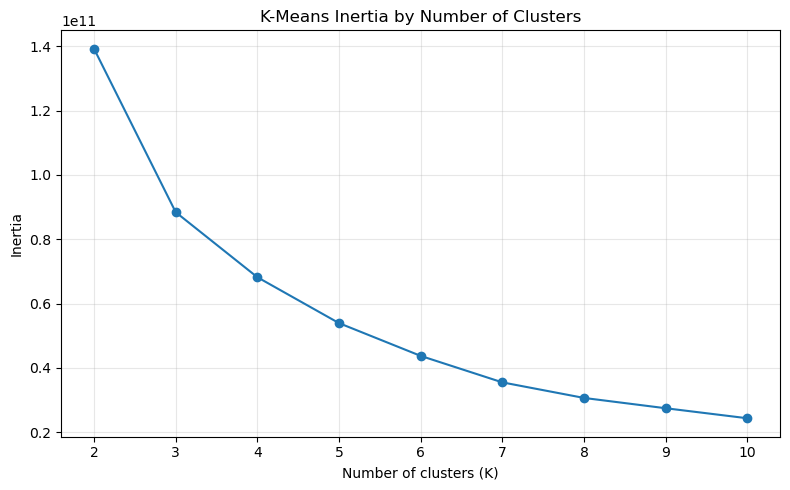

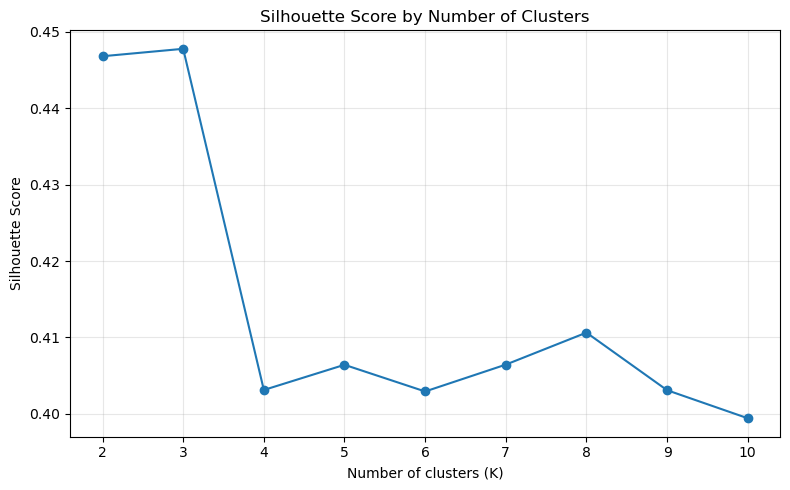


[저장 파일]
outputs\metrics\spatial_cluster_candidate_metrics.csv
outputs\figures\spatial_cluster_inertia_by_k.png
outputs\figures\spatial_cluster_silhouette_by_k.png


In [3]:
# 1. 위도·경도를 서울시 기준 평면 좌표로 변환한다.

EARTH_RADIUS_M = 6_371_000
RANDOM_STATE = 42

REFERENCE_LATITUDE = float(
    station_master["latitude"].mean()
)

REFERENCE_LONGITUDE = float(
    station_master["longitude"].mean()
)


latitude_radian = np.radians(
    station_master["latitude"].to_numpy(
        dtype=float
    )
)

longitude_radian = np.radians(
    station_master["longitude"].to_numpy(
        dtype=float
    )
)

reference_latitude_radian = np.radians(
    REFERENCE_LATITUDE
)

reference_longitude_radian = np.radians(
    REFERENCE_LONGITUDE
)


station_master_spatial = (
    station_master.copy()
)


station_master_spatial["x_meter"] = (
    EARTH_RADIUS_M
    * (
        longitude_radian
        - reference_longitude_radian
    )
    * np.cos(
        reference_latitude_radian
    )
)


station_master_spatial["y_meter"] = (
    EARTH_RADIUS_M
    * (
        latitude_radian
        - reference_latitude_radian
    )
)


coordinate_matrix = (
    station_master_spatial[
        [
            "x_meter",
            "y_meter",
        ]
    ]
    .to_numpy(
        dtype=float
    )
)


if not np.isfinite(
    coordinate_matrix
).all():
    raise ValueError(
        "변환된 평면 좌표에 비정상 값이 존재한다."
    )


print("[좌표 투영 결과]")
print(
    "기준 위도: "
    f"{REFERENCE_LATITUDE:.6f}"
)
print(
    "기준 경도: "
    f"{REFERENCE_LONGITUDE:.6f}"
)
print(
    "X축 범위: "
    f"{station_master_spatial['x_meter'].min():,.2f}m"
    " ~ "
    f"{station_master_spatial['x_meter'].max():,.2f}m"
)
print(
    "Y축 범위: "
    f"{station_master_spatial['y_meter'].min():,.2f}m"
    " ~ "
    f"{station_master_spatial['y_meter'].max():,.2f}m"
)


# 2. K-Means 군집 수 후보를 평가한다.

K_CANDIDATES = range(2, 11)

cluster_candidate_records = []
cluster_candidate_labels = {}
cluster_candidate_models = {}


total_rental_count = float(
    station_master_spatial[
        "rental_count"
    ].sum()
)


for n_clusters in K_CANDIDATES:
    model = KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE,
        n_init=50,
        max_iter=500,
    )


    labels = model.fit_predict(
        coordinate_matrix
    )


    cluster_candidate_models[
        n_clusters
    ] = model

    cluster_candidate_labels[
        n_clusters
    ] = labels


    station_count_by_cluster = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )


    candidate_demand = pd.DataFrame(
        {
            "cluster": labels,
            "rental_count": (
                station_master_spatial[
                    "rental_count"
                ]
                .to_numpy(
                    dtype=float
                )
            ),
        }
    )


    rental_count_by_cluster = (
        candidate_demand
        .groupby(
            "cluster"
        )["rental_count"]
        .sum()
        .sort_index()
    )


    rental_share_by_cluster = (
        rental_count_by_cluster
        .div(
            total_rental_count
        )
        .mul(100)
    )


    station_count_mean = float(
        station_count_by_cluster.mean()
    )


    station_count_std = float(
        station_count_by_cluster.std(
            ddof=0
        )
    )


    cluster_candidate_records.append(
        {
            "n_clusters": n_clusters,
            "inertia": float(
                model.inertia_
            ),
            "silhouette_score": float(
                silhouette_score(
                    coordinate_matrix,
                    labels,
                )
            ),
            "calinski_harabasz_score": float(
                calinski_harabasz_score(
                    coordinate_matrix,
                    labels,
                )
            ),
            "davies_bouldin_score": float(
                davies_bouldin_score(
                    coordinate_matrix,
                    labels,
                )
            ),
            "minimum_station_count": int(
                station_count_by_cluster.min()
            ),
            "maximum_station_count": int(
                station_count_by_cluster.max()
            ),
            "station_count_imbalance_ratio": float(
                station_count_by_cluster.max()
                / station_count_by_cluster.min()
            ),
            "station_count_cv": float(
                station_count_std
                / station_count_mean
            ),
            "minimum_rental_share_pct": float(
                rental_share_by_cluster.min()
            ),
            "maximum_rental_share_pct": float(
                rental_share_by_cluster.max()
            ),
            "rental_share_imbalance_ratio": float(
                rental_share_by_cluster.max()
                / rental_share_by_cluster.min()
            ),
        }
    )


cluster_candidate_evaluation = (
    pd.DataFrame(
        cluster_candidate_records
    )
    .sort_values(
        "n_clusters"
    )
    .reset_index(drop=True)
)


# 3. 지표별 최적 후보를 확인한다.

best_silhouette_k = int(
    cluster_candidate_evaluation.loc[
        cluster_candidate_evaluation[
            "silhouette_score"
        ].idxmax(),
        "n_clusters",
    ]
)


best_calinski_k = int(
    cluster_candidate_evaluation.loc[
        cluster_candidate_evaluation[
            "calinski_harabasz_score"
        ].idxmax(),
        "n_clusters",
    ]
)


best_davies_k = int(
    cluster_candidate_evaluation.loc[
        cluster_candidate_evaluation[
            "davies_bouldin_score"
        ].idxmin(),
        "n_clusters",
    ]
)


print("\n[군집 수 후보 평가]")
display(
    cluster_candidate_evaluation
)


print("\n[지표별 최적 군집 수]")
print(
    "Silhouette Score 기준: "
    f"K={best_silhouette_k}"
)
print(
    "Calinski-Harabasz Score 기준: "
    f"K={best_calinski_k}"
)
print(
    "Davies-Bouldin Score 기준: "
    f"K={best_davies_k}"
)


# 4. 군집 수별 평가 결과를 저장한다.

cluster_candidate_metrics_path = (
    METRICS_DIR
    / "spatial_cluster_candidate_metrics.csv"
)


cluster_candidate_evaluation.to_csv(
    cluster_candidate_metrics_path,
    index=False,
    encoding="utf-8-sig",
)


# 5. 군집 수별 Inertia를 시각화한다.

inertia_figure_path = (
    FIGURES_DIR
    / "spatial_cluster_inertia_by_k.png"
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    cluster_candidate_evaluation[
        "n_clusters"
    ],
    cluster_candidate_evaluation[
        "inertia"
    ],
    marker="o",
)

plt.xlabel(
    "Number of clusters (K)"
)

plt.ylabel(
    "Inertia"
)

plt.title(
    "K-Means Inertia by Number of Clusters"
)

plt.xticks(
    list(K_CANDIDATES)
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    inertia_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# 6. 군집 수별 Silhouette Score를 시각화한다.

silhouette_figure_path = (
    FIGURES_DIR
    / "spatial_cluster_silhouette_by_k.png"
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    cluster_candidate_evaluation[
        "n_clusters"
    ],
    cluster_candidate_evaluation[
        "silhouette_score"
    ],
    marker="o",
)

plt.xlabel(
    "Number of clusters (K)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Silhouette Score by Number of Clusters"
)

plt.xticks(
    list(K_CANDIDATES)
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    silhouette_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


print("\n[저장 파일]")
print(
    cluster_candidate_metrics_path.relative_to(
        ROOT
    )
)
print(
    inertia_figure_path.relative_to(
        ROOT
    )
)
print(
    silhouette_figure_path.relative_to(
        ROOT
    )
)

## 4. 최종 군집 수 선택 및 대여소 군집 확정

군집 수 후보 평가 결과 K=3에서 Silhouette Score가 0.447795로 가장 높게 나타났다. K=2의 점수와 차이는 크지 않지만, K=2는 서울시 대여소를 두 권역으로만 나누어 공간적 차이를 충분히 표현하기 어렵다.

K=4 이상에서는 군집 수가 증가함에도 Silhouette Score가 하락하고, 후속 수요예측에서 관리해야 하는 시계열 수가 증가한다. Calinski-Harabasz Score와 Davies-Bouldin Score는 각각 K=10과 K=7을 선호하지만, 해당 지표만을 기준으로 군집 수를 늘리면 분석 단위가 지나치게 세분화될 수 있다.

따라서 다음 사항을 종합하여 최종 군집 수를 3개로 결정한다.

* Silhouette Score가 후보 중 가장 높다.
* 각 군집에 충분한 수의 대여소와 이용건수가 포함된다.
* 서울시를 복수의 공간 권역으로 구분할 수 있다.
* 후속 SARIMA 및 LightGBM 수요예측의 복잡도를 적절하게 유지한다.

K-Means의 군집 번호는 실행 과정에서 임의로 부여될 수 있다. 재현 가능한 군집 번호를 만들기 위해 군집 중심의 X좌표를 기준으로 서쪽에서 동쪽 순서로 군집 번호를 0, 1, 2로 재부여한다.

이 단계에서는 지리적 위치만으로 군집을 생성한다. 대여량은 군집 평가와 해석에만 사용하며, K-Means 입력 변수에는 포함하지 않는다.


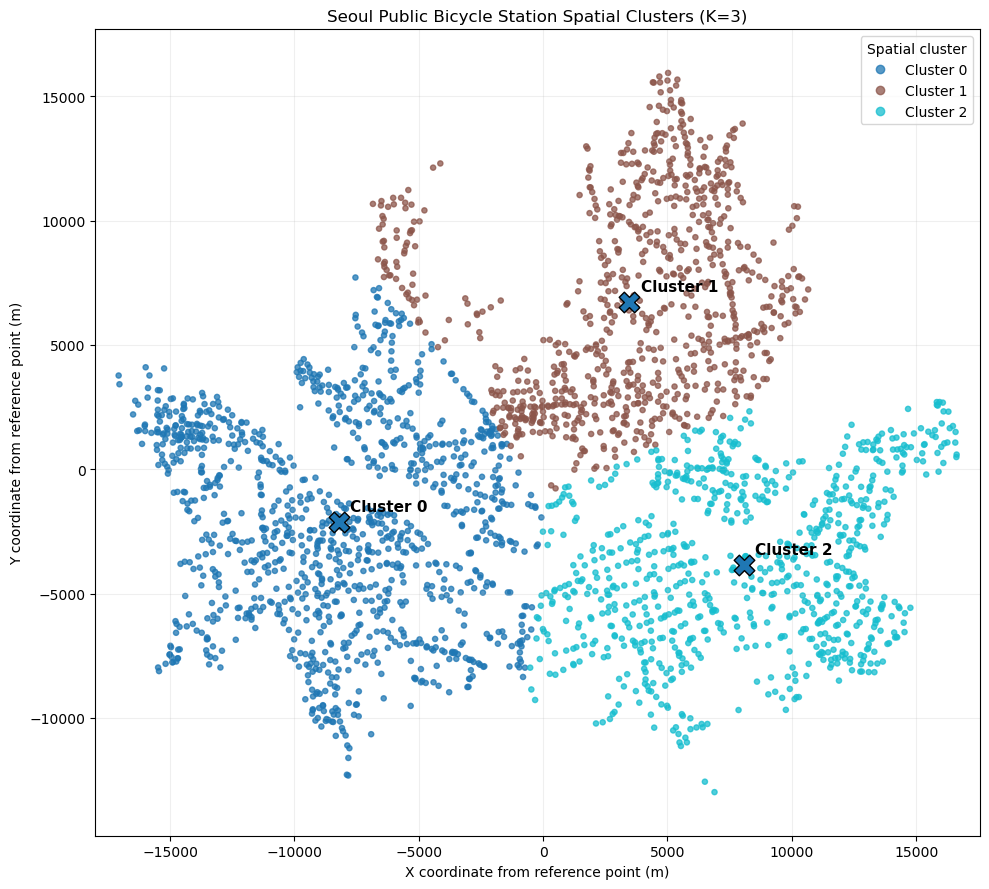

[최종 군집 설정]
최종 군집 수: 3개
군집 번호 정렬 기준: 군집 중심 X좌표의 서쪽→동쪽 순서
Silhouette Score: 0.447795
Calinski-Harabasz Score: 3206.318610
Davies-Bouldin Score: 0.818327

[군집별 요약]


,cluster_id,cluster_label,station_count,district_count,total_rental_count,mean_rental_count,median_rental_count,mean_distance_to_centroid_m,median_distance_to_centroid_m,p90_distance_to_centroid_m,...,minimum_latitude,maximum_latitude,minimum_longitude,maximum_longitude,centroid_x_meter,centroid_y_meter,centroid_latitude,centroid_longitude,station_share_pct,rental_share_pct
0,0,cluster_0,1172,14,42011493,35845.983788,27397.0,5314.468179,5496.293904,8055.261220,...,37.436981,37.617050,126.798599,126.991379,-8222.282083,-2108.038312,37.528763,126.898904,41.166140,47.358838
1,1,cluster_1,844,13,22855516,27079.995261,22103.5,5106.146627,5139.531498,7836.026009,...,37.540794,37.691013,126.914558,127.113060,3472.652194,6727.640944,37.608224,127.031560,29.645241,25.764632
2,2,cluster_2,831,8,23841868,28690.575211,19517.0,4958.919040,4822.992139,7786.562967,...,37.430977,37.572018,126.986282,127.180756,8069.309447,-3859.817154,37.513009,127.083699,29.188620,26.876530



[군집별 주요 자치구]


,cluster_id,cluster_label,district,station_count,station_share_within_cluster_pct,total_rental_count,rental_share_within_cluster_pct
0,0,cluster_0,강서구,199,16.979522,10564768,25.147328
1,0,cluster_0,영등포구,166,14.163823,7581690,18.046705
2,0,cluster_0,마포구,124,10.580205,4317787,10.277633
3,0,cluster_0,구로구,118,10.068259,3617762,8.611363
4,0,cluster_0,양천구,112,9.556314,5292097,12.596784
5,1,cluster_1,노원구,153,18.127962,5395794,23.608279
6,1,cluster_1,종로구,97,11.492891,2822858,12.350883
7,1,cluster_1,중랑구,97,11.492891,2541073,11.117986
8,1,cluster_1,동대문구,89,10.545024,2937015,12.850355
9,1,cluster_1,성북구,85,10.071090,2062987,9.026211



[저장 파일]
data\processed\station_cluster_map.csv
outputs\metrics\spatial_cluster_summary.csv
outputs\metrics\spatial_cluster_district_composition.csv
outputs\metrics\spatial_cluster_centroids.csv
outputs\figures\spatial_station_clusters_k3.png


In [4]:
import os

# wmic 경고를 출력하는 현상을 방지한다.
os.environ.setdefault(
    "LOKY_MAX_CPU_COUNT",
    str(os.cpu_count() or 1),
)


# 1. 최종 K-Means 모형을 적합한다.

FINAL_N_CLUSTERS = 3


final_kmeans = KMeans(
    n_clusters=FINAL_N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=50,
    max_iter=500,
)


raw_cluster_labels = (
    final_kmeans.fit_predict(
        coordinate_matrix
    )
)


raw_cluster_centers = (
    final_kmeans.cluster_centers_
)


if len(
    np.unique(raw_cluster_labels)
) != FINAL_N_CLUSTERS:
    raise ValueError(
        "최종 K-Means 모형에서 "
        "3개 군집이 생성되지 않았다."
    )


# 2. 군집 번호를 서쪽에서 동쪽 순서로 재부여한다.

# 군집 중심의 X좌표가 작을수록 서쪽에 위치한다.
raw_cluster_order = np.argsort(
    raw_cluster_centers[:, 0]
)


raw_to_stable_cluster = {
    int(raw_cluster_id): int(stable_cluster_id)
    for stable_cluster_id, raw_cluster_id
    in enumerate(raw_cluster_order)
}


stable_cluster_labels = np.array(
    [
        raw_to_stable_cluster[
            int(raw_cluster_id)
        ]
        for raw_cluster_id
        in raw_cluster_labels
    ],
    dtype=int,
)


stable_cluster_centers = np.vstack(
    [
        raw_cluster_centers[
            raw_cluster_id
        ]
        for raw_cluster_id
        in raw_cluster_order
    ]
)


cluster_label_map = {
    cluster_id: (
        f"cluster_{cluster_id}"
    )
    for cluster_id
    in range(FINAL_N_CLUSTERS)
}


# 3. 각 대여소와 군집 중심 사이의 거리를 계산한다.

station_centers = (
    stable_cluster_centers[
        stable_cluster_labels
    ]
)


distance_to_centroid_m = np.sqrt(
    np.square(
        coordinate_matrix
        - station_centers
    ).sum(axis=1)
)


if not np.isfinite(
    distance_to_centroid_m
).all():
    raise ValueError(
        "군집 중심까지의 거리에 "
        "비정상 값이 존재한다."
    )


# 4. 군집 중심의 위도·경도를 복원한다.

centroid_longitude = (
    REFERENCE_LONGITUDE
    + np.degrees(
        stable_cluster_centers[:, 0]
        / (
            EARTH_RADIUS_M
            * np.cos(
                reference_latitude_radian
            )
        )
    )
)


centroid_latitude = (
    REFERENCE_LATITUDE
    + np.degrees(
        stable_cluster_centers[:, 1]
        / EARTH_RADIUS_M
    )
)


cluster_centroid_table = pd.DataFrame(
    {
        "cluster_id": range(
            FINAL_N_CLUSTERS
        ),
        "cluster_label": [
            cluster_label_map[
                cluster_id
            ]
            for cluster_id
            in range(
                FINAL_N_CLUSTERS
            )
        ],
        "centroid_x_meter": (
            stable_cluster_centers[
                :,
                0,
            ]
        ),
        "centroid_y_meter": (
            stable_cluster_centers[
                :,
                1,
            ]
        ),
        "centroid_latitude": (
            centroid_latitude
        ),
        "centroid_longitude": (
            centroid_longitude
        ),
    }
)


# 5. 대여소별 최종 군집 매핑을 생성한다.

station_cluster_map = (
    station_master_spatial.copy()
)


station_cluster_map[
    "cluster_id"
] = stable_cluster_labels


station_cluster_map[
    "cluster_label"
] = (
    station_cluster_map[
        "cluster_id"
    ].map(
        cluster_label_map
    )
)


station_cluster_map[
    "distance_to_centroid_m"
] = distance_to_centroid_m


station_cluster_map = (
    station_cluster_map
    .sort_values(
        [
            "cluster_id",
            "station_id",
        ]
    )
    .reset_index(drop=True)
)


# 6. 군집별 규모와 수요를 요약한다.

cluster_summary = (
    station_cluster_map
    .groupby(
        [
            "cluster_id",
            "cluster_label",
        ],
        as_index=False,
    )
    .agg(
        station_count=(
            "station_id",
            "nunique",
        ),
        district_count=(
            "district",
            "nunique",
        ),
        total_rental_count=(
            "rental_count",
            "sum",
        ),
        mean_rental_count=(
            "rental_count",
            "mean",
        ),
        median_rental_count=(
            "rental_count",
            "median",
        ),
        mean_distance_to_centroid_m=(
            "distance_to_centroid_m",
            "mean",
        ),
        median_distance_to_centroid_m=(
            "distance_to_centroid_m",
            "median",
        ),
        p90_distance_to_centroid_m=(
            "distance_to_centroid_m",
            lambda values: (
                values.quantile(0.90)
            ),
        ),
        maximum_distance_to_centroid_m=(
            "distance_to_centroid_m",
            "max",
        ),
        minimum_latitude=(
            "latitude",
            "min",
        ),
        maximum_latitude=(
            "latitude",
            "max",
        ),
        minimum_longitude=(
            "longitude",
            "min",
        ),
        maximum_longitude=(
            "longitude",
            "max",
        ),
    )
    .merge(
        cluster_centroid_table,
        on=[
            "cluster_id",
            "cluster_label",
        ],
        how="left",
        validate="one_to_one",
    )
)


cluster_summary[
    "station_share_pct"
] = (
    cluster_summary[
        "station_count"
    ]
    .div(
        cluster_summary[
            "station_count"
        ].sum()
    )
    .mul(100)
)


cluster_summary[
    "rental_share_pct"
] = (
    cluster_summary[
        "total_rental_count"
    ]
    .div(
        cluster_summary[
            "total_rental_count"
        ].sum()
    )
    .mul(100)
)


cluster_summary = (
    cluster_summary
    .sort_values(
        "cluster_id"
    )
    .reset_index(drop=True)
)


# 7. 군집별 자치구 구성을 계산한다.

cluster_district_composition = (
    station_cluster_map
    .groupby(
        [
            "cluster_id",
            "cluster_label",
            "district",
        ],
        as_index=False,
    )
    .agg(
        station_count=(
            "station_id",
            "nunique",
        ),
        total_rental_count=(
            "rental_count",
            "sum",
        ),
    )
)


cluster_total_lookup = (
    cluster_summary[
        [
            "cluster_id",
            "station_count",
            "total_rental_count",
        ]
    ]
    .rename(
        columns={
            "station_count": (
                "cluster_station_count"
            ),
            "total_rental_count": (
                "cluster_rental_count"
            ),
        }
    )
)


cluster_district_composition = (
    cluster_district_composition
    .merge(
        cluster_total_lookup,
        on="cluster_id",
        how="left",
        validate="many_to_one",
    )
)


cluster_district_composition[
    "station_share_within_cluster_pct"
] = (
    cluster_district_composition[
        "station_count"
    ]
    .div(
        cluster_district_composition[
            "cluster_station_count"
        ]
    )
    .mul(100)
)


cluster_district_composition[
    "rental_share_within_cluster_pct"
] = (
    cluster_district_composition[
        "total_rental_count"
    ]
    .div(
        cluster_district_composition[
            "cluster_rental_count"
        ]
    )
    .mul(100)
)


cluster_district_composition = (
    cluster_district_composition
    .sort_values(
        [
            "cluster_id",
            "station_count",
            "total_rental_count",
            "district",
        ],
        ascending=[
            True,
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


top_districts_by_cluster = (
    cluster_district_composition
    .groupby(
        "cluster_id",
        group_keys=False,
    )
    .head(5)
    .reset_index(drop=True)
)


# 8. 최종 군집 결과를 검증한다.

EXPECTED_STATION_COUNT = 2_847
EXPECTED_RENTAL_COUNT = 88_708_877


cluster_id_set = set(
    station_cluster_map[
        "cluster_id"
    ].unique()
)


expected_cluster_id_set = set(
    range(
        FINAL_N_CLUSTERS
    )
)


if len(
    station_cluster_map
) != EXPECTED_STATION_COUNT:
    raise ValueError(
        "군집 매핑 대여소 수가 "
        f"{EXPECTED_STATION_COUNT:,}개와 다르다."
    )


if station_cluster_map[
    "station_id"
].duplicated().any():
    raise ValueError(
        "군집 매핑에 중복 대여소번호가 존재한다."
    )


if station_cluster_map[
    [
        "station_id",
        "cluster_id",
        "cluster_label",
        "latitude",
        "longitude",
        "distance_to_centroid_m",
    ]
].isna().any().any():
    raise ValueError(
        "군집 매핑 핵심 변수에 결측치가 존재한다."
    )


if (
    cluster_id_set
    != expected_cluster_id_set
):
    raise ValueError(
        "최종 군집 번호가 "
        f"{expected_cluster_id_set}와 다르다: "
        f"{cluster_id_set}"
    )


if int(
    station_cluster_map[
        "rental_count"
    ].sum()
) != EXPECTED_RENTAL_COUNT:
    raise ValueError(
        "군집 매핑의 이용건수 합계가 "
        f"{EXPECTED_RENTAL_COUNT:,}건과 다르다."
    )


if int(
    cluster_summary[
        "station_count"
    ].sum()
) != EXPECTED_STATION_COUNT:
    raise ValueError(
        "군집별 대여소 수 합계가 "
        "전체 대여소 수와 일치하지 않는다."
    )


if int(
    cluster_summary[
        "total_rental_count"
    ].sum()
) != EXPECTED_RENTAL_COUNT:
    raise ValueError(
        "군집별 이용건수 합계가 "
        "전체 이용건수와 일치하지 않는다."
    )


# 9. 최종 군집 결과를 저장한다.

station_cluster_map_path = (
    PROCESSED_DIR
    / "station_cluster_map.csv"
)


cluster_summary_path = (
    METRICS_DIR
    / "spatial_cluster_summary.csv"
)


cluster_district_path = (
    METRICS_DIR
    / "spatial_cluster_district_composition.csv"
)


cluster_centroid_path = (
    METRICS_DIR
    / "spatial_cluster_centroids.csv"
)


station_cluster_map[
    [
        "station_id",
        "station_name",
        "district",
        "address",
        "latitude",
        "longitude",
        "x_meter",
        "y_meter",
        "cluster_id",
        "cluster_label",
        "distance_to_centroid_m",
        "rental_count",
        "meaningful_coordinate_movement",
        "max_distance_m",
        "active_month_count",
        "first_active_month",
        "last_active_month",
    ]
].to_csv(
    station_cluster_map_path,
    index=False,
    encoding="utf-8-sig",
)


cluster_summary.to_csv(
    cluster_summary_path,
    index=False,
    encoding="utf-8-sig",
)


cluster_district_composition.to_csv(
    cluster_district_path,
    index=False,
    encoding="utf-8-sig",
)


cluster_centroid_table.to_csv(
    cluster_centroid_path,
    index=False,
    encoding="utf-8-sig",
)


# 10. 대여소 공간 군집을 시각화한다.

cluster_map_figure_path = (
    FIGURES_DIR
    / "spatial_station_clusters_k3.png"
)


plt.figure(
    figsize=(10, 9)
)


scatter = plt.scatter(
    station_cluster_map[
        "x_meter"
    ],
    station_cluster_map[
        "y_meter"
    ],
    c=station_cluster_map[
        "cluster_id"
    ],
    cmap="tab10",
    s=14,
    alpha=0.75,
)


plt.scatter(
    stable_cluster_centers[
        :,
        0,
    ],
    stable_cluster_centers[
        :,
        1,
    ],
    marker="X",
    s=220,
    edgecolor="black",
    linewidth=1.0,
)


for cluster_id, (
    centroid_x,
    centroid_y,
) in enumerate(
    stable_cluster_centers
):
    plt.annotate(
        f"Cluster {cluster_id}",
        xy=(
            centroid_x,
            centroid_y,
        ),
        xytext=(
            8,
            8,
        ),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
    )


legend_handles, legend_labels = (
    scatter.legend_elements()
)


plt.legend(
    legend_handles,
    [
        f"Cluster {cluster_id}"
        for cluster_id
        in range(
            FINAL_N_CLUSTERS
        )
    ],
    title="Spatial cluster",
    loc="best",
)


plt.xlabel(
    "X coordinate from reference point (m)"
)

plt.ylabel(
    "Y coordinate from reference point (m)"
)

plt.title(
    "Seoul Public Bicycle Station Spatial Clusters (K=3)"
)

plt.axis("equal")

plt.grid(
    alpha=0.2
)

plt.tight_layout()


plt.savefig(
    cluster_map_figure_path,
    dpi=200,
    bbox_inches="tight",
)


plt.show()


# 11. 최종 결과를 출력한다.

selected_candidate_result = (
    cluster_candidate_evaluation.loc[
        cluster_candidate_evaluation[
            "n_clusters"
        ].eq(
            FINAL_N_CLUSTERS
        )
    ]
    .iloc[0]
)


print("[최종 군집 설정]")
print(
    f"최종 군집 수: "
    f"{FINAL_N_CLUSTERS}개"
)
print(
    "군집 번호 정렬 기준: "
    "군집 중심 X좌표의 서쪽→동쪽 순서"
)
print(
    "Silhouette Score: "
    f"{selected_candidate_result['silhouette_score']:.6f}"
)
print(
    "Calinski-Harabasz Score: "
    f"{selected_candidate_result['calinski_harabasz_score']:.6f}"
)
print(
    "Davies-Bouldin Score: "
    f"{selected_candidate_result['davies_bouldin_score']:.6f}"
)


print("\n[군집별 요약]")
display(
    cluster_summary
)


print("\n[군집별 주요 자치구]")
display(
    top_districts_by_cluster[
        [
            "cluster_id",
            "cluster_label",
            "district",
            "station_count",
            "station_share_within_cluster_pct",
            "total_rental_count",
            "rental_share_within_cluster_pct",
        ]
    ]
)


print("\n[저장 파일]")
print(
    station_cluster_map_path.relative_to(
        ROOT
    )
)
print(
    cluster_summary_path.relative_to(
        ROOT
    )
)
print(
    cluster_district_path.relative_to(
        ROOT
    )
)
print(
    cluster_centroid_path.relative_to(
        ROOT
    )
)
print(
    cluster_map_figure_path.relative_to(
        ROOT
    )
)

## 5. 군집별 시간대 수요 집계 데이터 생성

앞 단계에서 각 대여소를 3개의 공간 군집으로 구분하였다. 이제 공간 분석용 시간대별 수요 데이터에 군집 정보를 결합하여, 군집 단위의 시간대별 총 대여건수를 집계한다.

이 단계의 목적은 다음과 같다.

* 대여소 단위의 고차원 수요 데이터를 군집 단위로 축약한다.
* 각 군집에 대해 하나의 시계열을 생성한다.
* 후속 시계열 예측 모형(SARIMA, LightGBM)의 입력 데이터셋을 구축한다.

집계 기준은 `datetime × cluster_id`이다. 같은 시각에 같은 군집에 속한 모든 대여소의 `rental_count`를 합산하여 군집별 시간대 수요를 계산한다.

최종 산출물은 다음과 같다.

* `data/processed/cluster_hourly_demand.csv`
* `outputs/metrics/cluster_hourly_demand_summary.csv`

또한 집계 결과에 대해 다음 항목을 검증한다.

* 군집 결합 후 누락 대여소가 없는지
* 전체 이용건수가 원본 공간 분석용 수요와 일치하는지
* `datetime × cluster_id` 조합이 유일한지
* 분석 기간 24개월이 모두 포함되는지


In [5]:
# 1. 입력 파일 경로 설정

cluster_map_path = (
    PROCESSED_DIR
    / "station_cluster_map.csv"
)

spatial_monthly_dir = (
    PROCESSED_DIR
    / "station_hourly_spatial_monthly"
)

cluster_hourly_output_path = (
    PROCESSED_DIR
    / "cluster_hourly_demand.csv"
)

cluster_hourly_summary_path = (
    METRICS_DIR
    / "cluster_hourly_demand_summary.csv"
)


# 2. 입력 데이터 로드

station_cluster_map_for_merge = pd.read_csv(
    cluster_map_path
)

station_cluster_map_for_merge["station_id"] = (
    pd.to_numeric(
        station_cluster_map_for_merge["station_id"],
        errors="coerce",
    )
    .astype("Int64")
)

station_cluster_map_for_merge = (
    station_cluster_map_for_merge[
        [
            "station_id",
            "cluster_id",
            "cluster_label",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)


spatial_monthly_files = sorted(
    spatial_monthly_dir.glob(
        "station_hourly_*.csv"
    )
)

if len(spatial_monthly_files) != 24:
    raise ValueError(
        "공간 분석용 월별 파일 수가 "
        "24개가 아니다."
    )


# 3. 월별 파일을 읽어 군집 정보 결합 후 집계

cluster_hourly_frames = []
cluster_hourly_summary_records = []

for monthly_file in spatial_monthly_files:
    monthly_data = pd.read_csv(
        monthly_file
    )

    monthly_data["datetime"] = pd.to_datetime(
        monthly_data["datetime"],
        errors="coerce",
    )

    monthly_data["station_id"] = (
        pd.to_numeric(
            monthly_data["station_id"],
            errors="coerce",
        )
        .astype("Int64")
    )

    monthly_data["rental_count"] = pd.to_numeric(
        monthly_data["rental_count"],
        errors="coerce",
    )

    monthly_data["year_month"] = (
        monthly_data["datetime"]
        .dt.to_period("M")
        .astype(str)
    )

    expected_year_month = (
        monthly_file.stem.replace(
            "station_hourly_",
            ""
        )
    )

    expected_period_text = (
        f"{expected_year_month[:4]}-"
        f"{expected_year_month[4:]}"
    )

    month_mismatch_count = (
        (
            monthly_data["year_month"].notna()
        )
        & (
            monthly_data["year_month"]
            != expected_period_text
        )
    ).sum()

    if month_mismatch_count != 0:
        raise ValueError(
            f"{monthly_file.name} 파일의 "
            "datetime과 파일명이 일치하지 않는다."
        )

    merged_monthly = monthly_data.merge(
        station_cluster_map_for_merge,
        on="station_id",
        how="left",
        validate="many_to_one",
    )

    unmatched_station_count = int(
        merged_monthly["cluster_id"]
        .isna()
        .sum()
    )

    if unmatched_station_count != 0:
        raise ValueError(
            f"{monthly_file.name}에서 "
            "군집 정보가 결합되지 않은 행이 존재한다."
        )

    grouped_monthly = (
        merged_monthly
        .groupby(
            [
                "datetime",
                "cluster_id",
                "cluster_label",
            ],
            as_index=False,
        )["rental_count"]
        .sum()
        .sort_values(
            ["datetime", "cluster_id"]
        )
        .reset_index(drop=True)
    )

    grouped_monthly["year_month"] = (
        grouped_monthly["datetime"]
        .dt.to_period("M")
        .astype(str)
    )

    cluster_hourly_frames.append(
        grouped_monthly
    )

    cluster_hourly_summary_records.append(
        {
            "year_month": expected_year_month,
            "input_file": monthly_file.name,
            "input_row_count": len(monthly_data),
            "output_row_count": len(grouped_monthly),
            "input_station_count": monthly_data[
                "station_id"
            ].nunique(),
            "cluster_count": grouped_monthly[
                "cluster_id"
            ].nunique(),
            "input_rental_count": int(
                monthly_data["rental_count"]
                .sum()
            ),
            "output_rental_count": int(
                grouped_monthly["rental_count"]
                .sum()
            ),
        }
    )


# 4. 전체 군집 시계열 결합

cluster_hourly_demand = pd.concat(
    cluster_hourly_frames,
    axis=0,
    ignore_index=True,
)

cluster_hourly_demand = (
    cluster_hourly_demand
    .sort_values(
        ["datetime", "cluster_id"]
    )
    .reset_index(drop=True)
)

cluster_hourly_summary = pd.DataFrame(
    cluster_hourly_summary_records
)


# 5. 검증

EXPECTED_CLUSTER_COUNT = 3
EXPECTED_TOTAL_RENTAL_COUNT = 88_708_877
EXPECTED_PERIOD_COUNT = 24

duplicate_key_count = int(
    cluster_hourly_demand.duplicated(
        subset=["datetime", "cluster_id"]
    ).sum()
)

missing_core_value_count = int(
    cluster_hourly_demand[
        [
            "datetime",
            "cluster_id",
            "cluster_label",
            "rental_count",
        ]
    ]
    .isna()
    .sum()
    .sum()
)

negative_rental_count = int(
    (cluster_hourly_demand["rental_count"] < 0).sum()
)

total_rental_count = int(
    cluster_hourly_demand["rental_count"].sum()
)

period_count = int(
    cluster_hourly_demand["year_month"]
    .nunique()
)

cluster_count = int(
    cluster_hourly_demand["cluster_id"]
    .nunique()
)

if duplicate_key_count != 0:
    raise ValueError(
        "군집별 시간대 수요 데이터에 "
        "중복 키(datetime, cluster_id)가 존재한다."
    )

if missing_core_value_count != 0:
    raise ValueError(
        "군집별 시간대 수요 데이터에 "
        "핵심 변수 결측이 존재한다."
    )

if negative_rental_count != 0:
    raise ValueError(
        "군집별 시간대 수요 데이터에 "
        "음수 이용건수가 존재한다."
    )

if total_rental_count != EXPECTED_TOTAL_RENTAL_COUNT:
    raise ValueError(
        "군집별 시간대 수요 합계가 "
        "공간 분석용 전체 이용건수와 일치하지 않는다."
    )

if period_count != EXPECTED_PERIOD_COUNT:
    raise ValueError(
        "군집별 시간대 수요 데이터의 "
        "관측월 수가 24개월이 아니다."
    )

if cluster_count != EXPECTED_CLUSTER_COUNT:
    raise ValueError(
        "군집 수가 3개가 아니다."
    )

if not (
    cluster_hourly_summary["input_rental_count"]
    .eq(cluster_hourly_summary["output_rental_count"])
    .all()
):
    raise ValueError(
        "일부 월에서 집계 전후 이용건수가 보존되지 않았다."
    )


# 6. 저장

cluster_hourly_demand.to_csv(
    cluster_hourly_output_path,
    index=False,
    encoding="utf-8-sig",
)

cluster_hourly_summary.to_csv(
    cluster_hourly_summary_path,
    index=False,
    encoding="utf-8-sig",
)


# 7. 출력

print("[군집별 시간대 수요 구축 결과]")
print(
    f"월별 입력 파일 수: {len(spatial_monthly_files)}개"
)
print(
    f"최종 집계 행 수: {len(cluster_hourly_demand):,}행"
)
print(
    f"관측월 수: {period_count}개월"
)
print(
    f"군집 수: {cluster_count}개"
)
print(
    f"전체 이용건수: {total_rental_count:,}건"
)
print(
    f"중복 키 수: {duplicate_key_count}"
)
print(
    f"핵심 변수 결측 수: {missing_core_value_count}"
)

print("\n[월별 군집 수요 집계 요약]")
display(cluster_hourly_summary)

print("\n[군집별 시간대 수요 표본]")
display(
    cluster_hourly_demand.head(20)
)

print("\n[저장 파일]")
print(
    cluster_hourly_output_path.relative_to(ROOT)
)
print(
    cluster_hourly_summary_path.relative_to(ROOT)
)

[군집별 시간대 수요 구축 결과]
월별 입력 파일 수: 24개
최종 집계 행 수: 52,632행
관측월 수: 24개월
군집 수: 3개
전체 이용건수: 88,708,877건
중복 키 수: 0
핵심 변수 결측 수: 0

[월별 군집 수요 집계 요약]


,year_month,input_file,input_row_count,output_row_count,input_station_count,cluster_count,input_rental_count,output_rental_count
0,202301,station_hourly_202301.csv,752615,2232,2694,3,1565736,1565736
1,202302,station_hourly_202302.csv,893812,2016,2700,3,2223894,2223894
2,202303,station_hourly_202303.csv,1158142,2232,2709,3,3874617,3874617
3,202304,station_hourly_202304.csv,1126112,2160,2709,3,4073053,4073053
4,202305,station_hourly_202305.csv,1199497,2232,2716,3,4946583,4946583
5,202306,station_hourly_202306.csv,1224443,2160,2712,3,4932262,4932262
6,202307,station_hourly_202307.csv,1128244,2232,2732,3,3931806,3931806
7,202308,station_hourly_202308.csv,1153861,2232,2728,3,3935272,3935272
8,202309,station_hourly_202309.csv,1168556,2160,2728,3,4548821,4548821
9,202310,station_hourly_202310.csv,1303240,2232,2732,3,5293021,5293021



[군집별 시간대 수요 표본]


,datetime,cluster_id,cluster_label,rental_count,year_month
0,2023-01-01 00:00:00,0,cluster_0,641,2023-01
1,2023-01-01 00:00:00,1,cluster_1,521,2023-01
2,2023-01-01 00:00:00,2,cluster_2,399,2023-01
3,2023-01-01 01:00:00,0,cluster_0,822,2023-01
4,2023-01-01 01:00:00,1,cluster_1,440,2023-01
5,2023-01-01 01:00:00,2,cluster_2,387,2023-01
6,2023-01-01 02:00:00,0,cluster_0,515,2023-01
7,2023-01-01 02:00:00,1,cluster_1,343,2023-01
8,2023-01-01 02:00:00,2,cluster_2,288,2023-01
9,2023-01-01 03:00:00,0,cluster_0,392,2023-01



[저장 파일]
data\processed\cluster_hourly_demand.csv
outputs\metrics\cluster_hourly_demand_summary.csv


## 6. 군집별 수요 시계열 탐색

군집별 시간대 수요 데이터가 2023년 1월 1일 00시부터 2024년 12월 31일 23시까지 한 시간 간격으로 연속적으로 구성되었는지 확인한다.

이후 후속 수요예측 모델의 특성 설계와 계절성 설정을 위해 다음 패턴을 분석한다.

- 군집별 수요의 평균, 중앙값, 표준편차 및 극단값
- 시간대별 평균 수요
- 요일별 평균 수요
- 월별 총수요 및 시간당 평균 수요
- 일별 수요 변화
- 1시간, 24시간, 168시간 시차 자기상관

24시간 시차 자기상관은 전날 같은 시간대와의 유사성을, 168시간 시차 자기상관은 전주 같은 요일·시간대와의 유사성을 나타낸다. 이 결과를 통해 일중 계절성과 주간 계절성이 실제 데이터에 존재하는지 확인한다.

[시계열 완전성 검증]
전체 기간: 2023-01-01 00:00:00 ~ 2024-12-31 23:00:00
군집별 예상 시간 수: 17,544시간
전체 예상 행 수: 52,632행
전체 실제 행 수: 52,632행
중복 키 수: 0개
핵심 변수 결측 수: 0개
누락 시간이 있는 군집 수: 0개

[군집별 시간축 완전성]


,cluster_id,cluster_label,expected_hour_count,observed_hour_count,missing_hour_count,extra_hour_count,duplicated_hour_count,cluster_label_count,first_datetime,last_datetime,is_complete
0,0,cluster_0,17544,17544,0,0,0,1,2023-01-01,2024-12-31 23:00:00,True
1,1,cluster_1,17544,17544,0,0,0,1,2023-01-01,2024-12-31 23:00:00,True
2,2,cluster_2,17544,17544,0,0,0,1,2023-01-01,2024-12-31 23:00:00,True


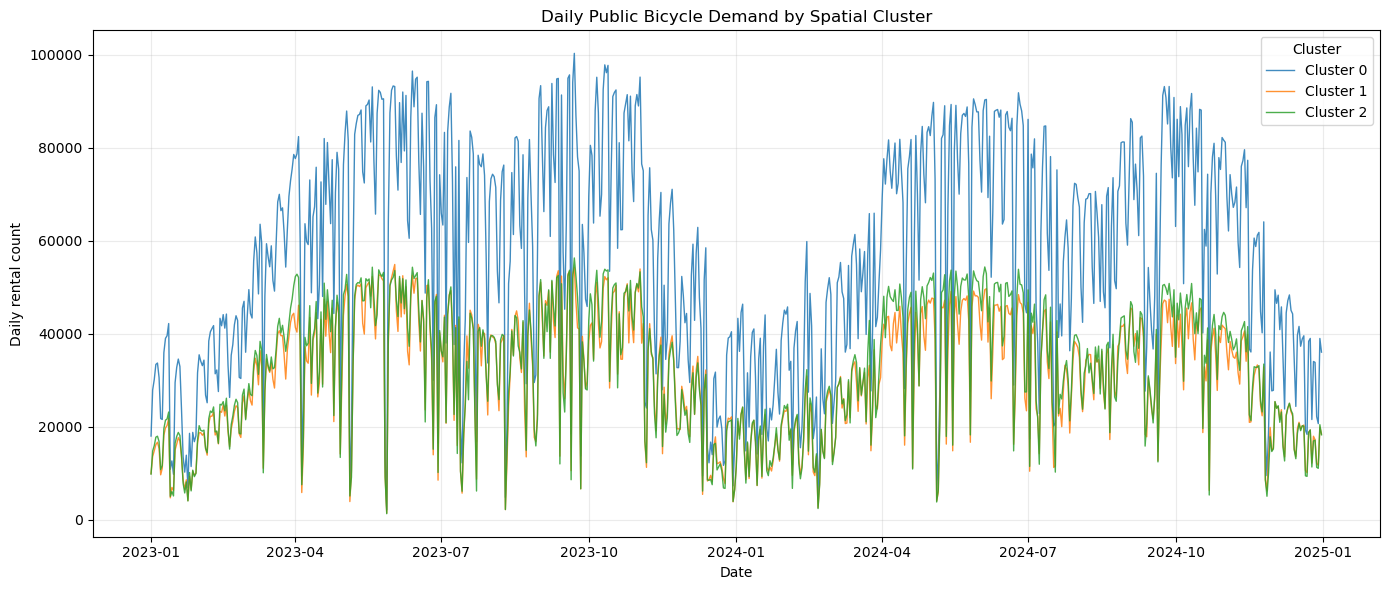

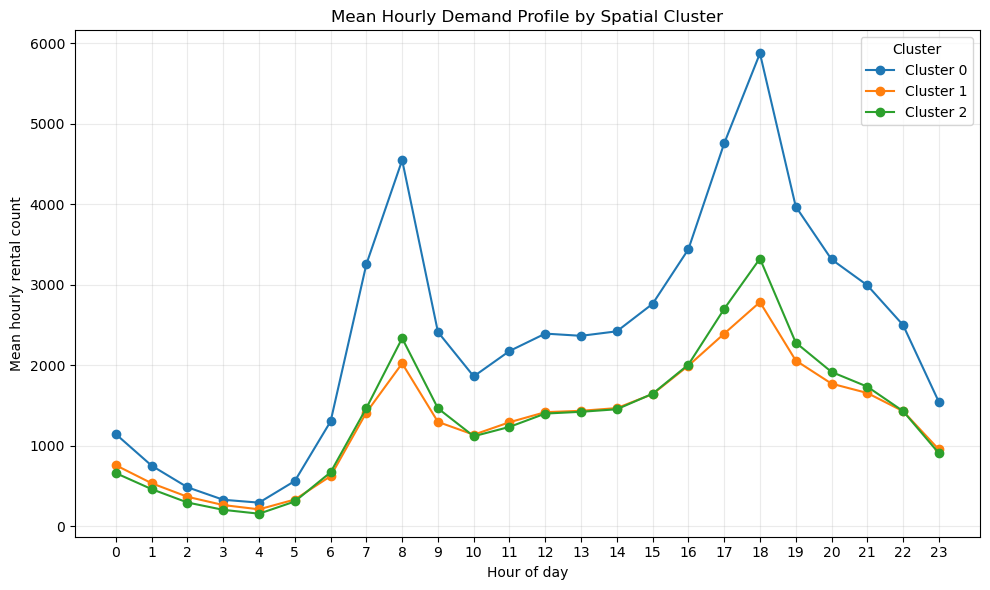

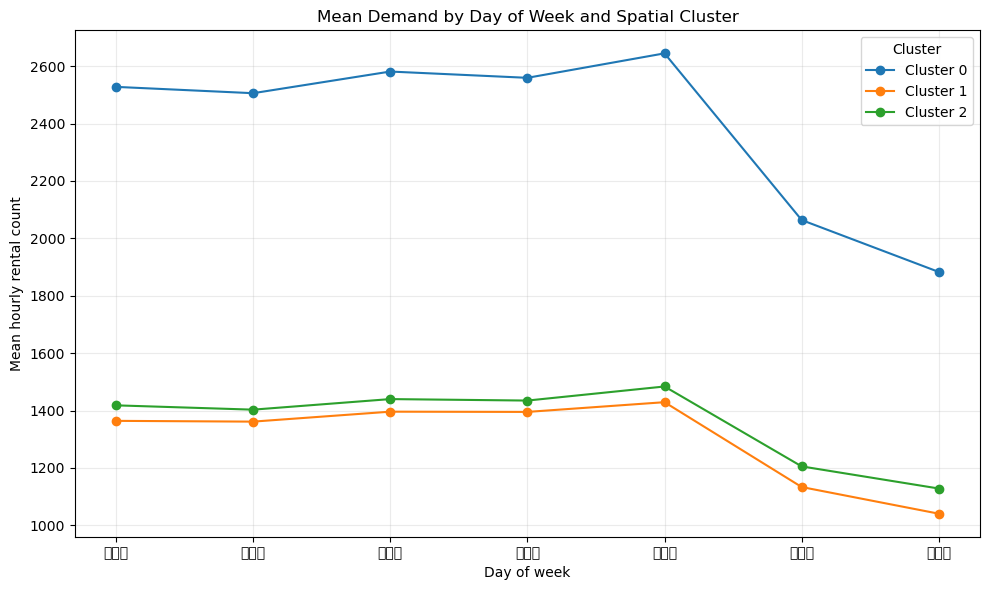

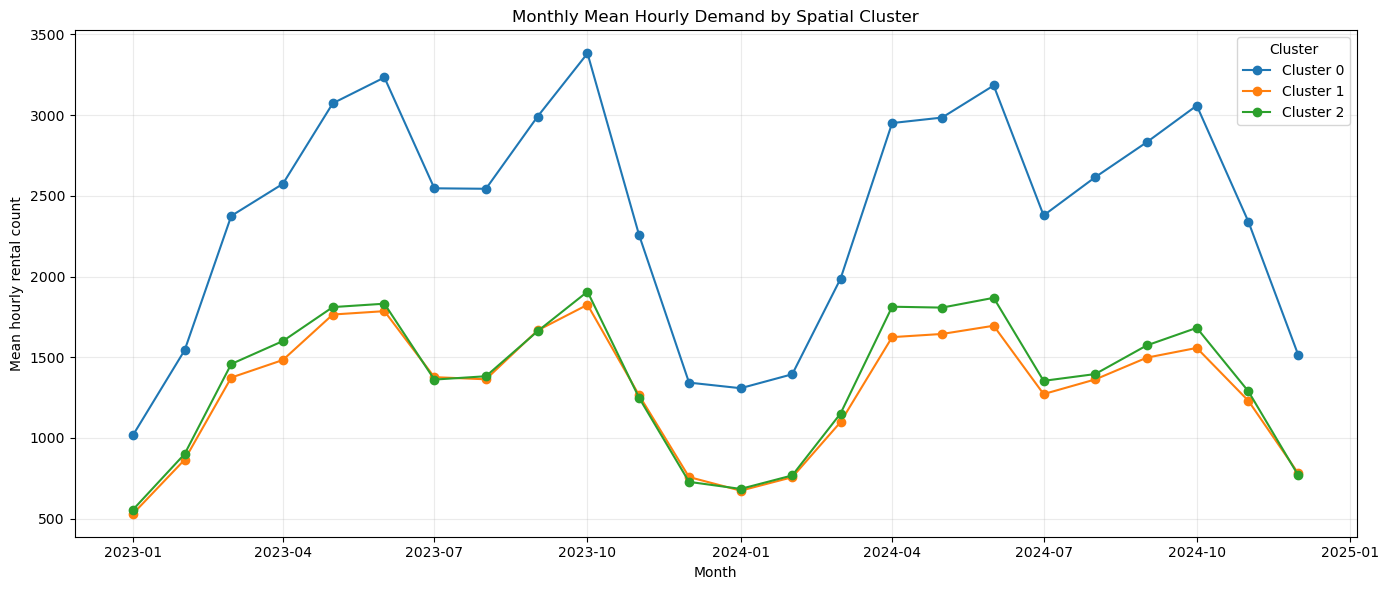


[군집별 수요 기술통계]


,cluster_id,cluster_label,observation_count,total_rental_count,mean_hourly_demand,std_hourly_demand,minimum_hourly_demand,q25_hourly_demand,median_hourly_demand,q75_hourly_demand,p95_hourly_demand,maximum_hourly_demand,coefficient_of_variation
0,0,cluster_0,17544,42011493,2394.635944,2055.886565,9,730.00,1940.5,3379.00,6587.55,12325,0.858538
1,1,cluster_1,17544,22855516,1302.753990,996.412312,8,456.00,1113.0,1907.00,3198.00,5629,0.764851
2,2,cluster_2,17544,23841868,1358.975604,1156.869595,7,411.75,1096.0,1966.25,3681.00,6735,0.851281



[군집별 주요 시차 자기상관]


,cluster_id,cluster_label,lag_1_hour,lag_24_hours,lag_168_hours
0,0,cluster_0,0.827473,0.746591,0.766378
1,1,cluster_1,0.881299,0.741256,0.740114
2,2,cluster_2,0.857453,0.755962,0.757953



[시간대별 평균 수요]


,cluster_id,cluster_label,hour,mean_rental_count
0,0,cluster_0,0,1144.153215
1,0,cluster_0,1,752.805746
2,0,cluster_0,2,485.136799
3,0,cluster_0,3,329.911081
4,0,cluster_0,4,294.395349
...,...,...,...,...
67,2,cluster_2,19,2281.979480
68,2,cluster_2,20,1917.616963
69,2,cluster_2,21,1734.625171
70,2,cluster_2,22,1431.041040



[요일별 평균 수요]


,cluster_id,cluster_label,weekday,weekday_label,mean_rental_count
0,0,cluster_0,0,월요일,2527.749603
1,0,cluster_0,1,화요일,2505.695635
2,0,cluster_0,2,수요일,2581.153846
3,0,cluster_0,3,목요일,2559.287260
4,0,cluster_0,4,금요일,2644.534054
5,0,cluster_0,5,토요일,2063.743590
6,0,cluster_0,6,일요일,1882.860714
7,1,cluster_1,0,월요일,1364.168254
8,1,cluster_1,1,화요일,1361.485714
9,1,cluster_1,2,수요일,1396.167468



[저장 파일]
outputs\metrics\cluster_time_series_completeness.csv
outputs\metrics\cluster_demand_descriptive_stats.csv
outputs\metrics\cluster_hourly_profile.csv
outputs\metrics\cluster_weekday_profile.csv
outputs\metrics\cluster_monthly_profile.csv
outputs\metrics\cluster_daily_demand.csv
outputs\metrics\cluster_autocorrelation_summary.csv
outputs\figures\cluster_daily_demand_timeseries.png
outputs\figures\cluster_hourly_demand_profile.png
outputs\figures\cluster_weekday_demand_profile.png
outputs\figures\cluster_monthly_mean_demand.png


In [6]:
# 1. 군집별 시간대 수요 데이터를 다시 불러온다.

CLUSTER_HOURLY_PATH = (
    PROCESSED_DIR
    / "cluster_hourly_demand.csv"
)


if not CLUSTER_HOURLY_PATH.exists():
    raise FileNotFoundError(
        "군집별 시간대 수요 파일이 존재하지 않는다: "
        f"{CLUSTER_HOURLY_PATH.relative_to(ROOT)}"
    )


cluster_hourly_demand = pd.read_csv(
    CLUSTER_HOURLY_PATH,
    encoding="utf-8-sig",
    dtype={
        "cluster_id": "Int64",
        "cluster_label": "string",
    },
    parse_dates=[
        "datetime",
    ],
)


required_columns = {
    "datetime",
    "cluster_id",
    "cluster_label",
    "rental_count",
}


missing_columns = sorted(
    required_columns
    - set(cluster_hourly_demand.columns)
)


if missing_columns:
    raise KeyError(
        "군집별 시간대 수요 데이터에 필수 컬럼이 없다: "
        f"{missing_columns}"
    )


cluster_hourly_demand[
    "rental_count"
] = pd.to_numeric(
    cluster_hourly_demand[
        "rental_count"
    ],
    errors="coerce",
)


cluster_hourly_demand = (
    cluster_hourly_demand
    .sort_values(
        [
            "datetime",
            "cluster_id",
        ]
    )
    .reset_index(drop=True)
)


# 2. 시간축의 완전성을 검증한다.

EXPECTED_START_DATETIME = pd.Timestamp(
    "2023-01-01 00:00:00"
)

EXPECTED_END_DATETIME = pd.Timestamp(
    "2024-12-31 23:00:00"
)

EXPECTED_CLUSTER_IDS = {
    0,
    1,
    2,
}


expected_datetime_index = pd.date_range(
    start=EXPECTED_START_DATETIME,
    end=EXPECTED_END_DATETIME,
    freq="h",
)


EXPECTED_HOUR_COUNT = len(
    expected_datetime_index
)

EXPECTED_TOTAL_ROW_COUNT = (
    EXPECTED_HOUR_COUNT
    * len(EXPECTED_CLUSTER_IDS)
)

EXPECTED_TOTAL_RENTAL_COUNT = (
    88_708_877
)


duplicate_key_count = int(
    cluster_hourly_demand.duplicated(
        subset=[
            "datetime",
            "cluster_id",
        ]
    ).sum()
)


core_missing_count = int(
    cluster_hourly_demand[
        [
            "datetime",
            "cluster_id",
            "cluster_label",
            "rental_count",
        ]
    ]
    .isna()
    .sum()
    .sum()
)


negative_rental_count = int(
    cluster_hourly_demand[
        "rental_count"
    ]
    .lt(0)
    .fillna(False)
    .sum()
)


non_integer_rental_count = int(
    (
        cluster_hourly_demand[
            "rental_count"
        ].notna()
        & ~cluster_hourly_demand[
            "rental_count"
        ].mod(1).eq(0)
    ).sum()
)


observed_cluster_ids = set(
    cluster_hourly_demand[
        "cluster_id"
    ]
    .dropna()
    .astype(int)
    .unique()
)


if duplicate_key_count != 0:
    raise ValueError(
        "datetime과 cluster_id 조합에 "
        f"중복이 존재한다: {duplicate_key_count:,}개"
    )


if core_missing_count != 0:
    raise ValueError(
        "군집별 시계열의 핵심 변수에 "
        f"결측치가 존재한다: {core_missing_count:,}개"
    )


if negative_rental_count != 0:
    raise ValueError(
        "군집별 시계열에 음수 이용건수가 존재한다: "
        f"{negative_rental_count:,}개"
    )


if non_integer_rental_count != 0:
    raise ValueError(
        "군집별 시계열에 비정수 이용건수가 존재한다: "
        f"{non_integer_rental_count:,}개"
    )


if observed_cluster_ids != EXPECTED_CLUSTER_IDS:
    raise ValueError(
        "군집 번호가 예상값과 다르다: "
        f"{observed_cluster_ids}"
    )


if (
    len(cluster_hourly_demand)
    != EXPECTED_TOTAL_ROW_COUNT
):
    raise ValueError(
        "군집별 시계열 행 수가 예상값과 다르다: "
        f"{len(cluster_hourly_demand):,}행"
    )


if int(
    cluster_hourly_demand[
        "rental_count"
    ].sum()
) != EXPECTED_TOTAL_RENTAL_COUNT:
    raise ValueError(
        "군집별 시계열 이용건수 합계가 "
        f"{EXPECTED_TOTAL_RENTAL_COUNT:,}건과 다르다."
    )


# 3. 군집별 시각 연속성을 확인한다.

completeness_records = []


for cluster_id in sorted(
    EXPECTED_CLUSTER_IDS
):
    cluster_data = (
        cluster_hourly_demand.loc[
            cluster_hourly_demand[
                "cluster_id"
            ].eq(cluster_id)
        ]
        .copy()
        .sort_values("datetime")
    )


    observed_datetime_index = pd.DatetimeIndex(
        cluster_data[
            "datetime"
        ]
    )


    missing_datetime_index = (
        expected_datetime_index.difference(
            observed_datetime_index
        )
    )


    extra_datetime_index = (
        observed_datetime_index.difference(
            expected_datetime_index
        )
    )


    duplicated_datetime_count = int(
        observed_datetime_index.duplicated().sum()
    )


    label_count = int(
        cluster_data[
            "cluster_label"
        ].nunique()
    )


    completeness_records.append(
        {
            "cluster_id": cluster_id,
            "cluster_label": (
                cluster_data[
                    "cluster_label"
                ].iloc[0]
            ),
            "expected_hour_count": (
                EXPECTED_HOUR_COUNT
            ),
            "observed_hour_count": (
                len(cluster_data)
            ),
            "missing_hour_count": (
                len(missing_datetime_index)
            ),
            "extra_hour_count": (
                len(extra_datetime_index)
            ),
            "duplicated_hour_count": (
                duplicated_datetime_count
            ),
            "cluster_label_count": (
                label_count
            ),
            "first_datetime": (
                cluster_data[
                    "datetime"
                ].min()
            ),
            "last_datetime": (
                cluster_data[
                    "datetime"
                ].max()
            ),
            "is_complete": (
                len(cluster_data)
                == EXPECTED_HOUR_COUNT
                and len(
                    missing_datetime_index
                ) == 0
                and len(
                    extra_datetime_index
                ) == 0
                and duplicated_datetime_count == 0
                and label_count == 1
            ),
        }
    )


cluster_time_completeness = pd.DataFrame(
    completeness_records
)


if not cluster_time_completeness[
    "is_complete"
].all():
    print("[불완전한 군집 시계열]")
    display(
        cluster_time_completeness.loc[
            ~cluster_time_completeness[
                "is_complete"
            ]
        ]
    )

    raise ValueError(
        "일부 군집에서 시간대 시계열이 "
        "완전하게 구성되지 않았다."
    )


print("[시계열 완전성 검증]")
print(
    f"전체 기간: "
    f"{EXPECTED_START_DATETIME} "
    f"~ {EXPECTED_END_DATETIME}"
)
print(
    f"군집별 예상 시간 수: "
    f"{EXPECTED_HOUR_COUNT:,}시간"
)
print(
    f"전체 예상 행 수: "
    f"{EXPECTED_TOTAL_ROW_COUNT:,}행"
)
print(
    f"전체 실제 행 수: "
    f"{len(cluster_hourly_demand):,}행"
)
print(
    f"중복 키 수: "
    f"{duplicate_key_count:,}개"
)
print(
    f"핵심 변수 결측 수: "
    f"{core_missing_count:,}개"
)
print(
    f"누락 시간이 있는 군집 수: "
    f"{(~cluster_time_completeness['is_complete']).sum():,}개"
)


print("\n[군집별 시간축 완전성]")
display(
    cluster_time_completeness
)


# 4. 시간 관련 파생변수를 생성한다.

WEEKDAY_ORDER = [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
]


WEEKDAY_LABEL_MAP = {
    0: "월요일",
    1: "화요일",
    2: "수요일",
    3: "목요일",
    4: "금요일",
    5: "토요일",
    6: "일요일",
}


cluster_hourly_eda = (
    cluster_hourly_demand.copy()
)


cluster_hourly_eda[
    "date"
] = (
    cluster_hourly_eda[
        "datetime"
    ].dt.floor("D")
)


cluster_hourly_eda[
    "year"
] = (
    cluster_hourly_eda[
        "datetime"
    ].dt.year
)


cluster_hourly_eda[
    "month"
] = (
    cluster_hourly_eda[
        "datetime"
    ].dt.month
)


cluster_hourly_eda[
    "year_month"
] = (
    cluster_hourly_eda[
        "datetime"
    ]
    .dt.to_period("M")
    .astype("string")
)


cluster_hourly_eda[
    "hour"
] = (
    cluster_hourly_eda[
        "datetime"
    ].dt.hour
)


cluster_hourly_eda[
    "weekday"
] = (
    cluster_hourly_eda[
        "datetime"
    ].dt.dayofweek
)


cluster_hourly_eda[
    "weekday_label"
] = (
    cluster_hourly_eda[
        "weekday"
    ].map(
        WEEKDAY_LABEL_MAP
    )
)


cluster_hourly_eda[
    "is_weekend"
] = (
    cluster_hourly_eda[
        "weekday"
    ].isin(
        [
            5,
            6,
        ]
    )
)


# 5. 군집별 기술통계량을 계산한다.

cluster_demand_descriptive_stats = (
    cluster_hourly_eda
    .groupby(
        [
            "cluster_id",
            "cluster_label",
        ],
        as_index=False,
    )
    .agg(
        observation_count=(
            "rental_count",
            "size",
        ),
        total_rental_count=(
            "rental_count",
            "sum",
        ),
        mean_hourly_demand=(
            "rental_count",
            "mean",
        ),
        std_hourly_demand=(
            "rental_count",
            "std",
        ),
        minimum_hourly_demand=(
            "rental_count",
            "min",
        ),
        q25_hourly_demand=(
            "rental_count",
            lambda values: (
                values.quantile(0.25)
            ),
        ),
        median_hourly_demand=(
            "rental_count",
            "median",
        ),
        q75_hourly_demand=(
            "rental_count",
            lambda values: (
                values.quantile(0.75)
            ),
        ),
        p95_hourly_demand=(
            "rental_count",
            lambda values: (
                values.quantile(0.95)
            ),
        ),
        maximum_hourly_demand=(
            "rental_count",
            "max",
        ),
    )
)


cluster_demand_descriptive_stats[
    "coefficient_of_variation"
] = (
    cluster_demand_descriptive_stats[
        "std_hourly_demand"
    ]
    .div(
        cluster_demand_descriptive_stats[
            "mean_hourly_demand"
        ]
    )
)


# 6. 시간대별 수요 패턴을 계산한다.

cluster_hourly_profile = (
    cluster_hourly_eda
    .groupby(
        [
            "cluster_id",
            "cluster_label",
            "hour",
        ],
        as_index=False,
    )
    .agg(
        mean_rental_count=(
            "rental_count",
            "mean",
        ),
        median_rental_count=(
            "rental_count",
            "median",
        ),
        std_rental_count=(
            "rental_count",
            "std",
        ),
        total_rental_count=(
            "rental_count",
            "sum",
        ),
    )
    .sort_values(
        [
            "cluster_id",
            "hour",
        ]
    )
    .reset_index(drop=True)
)


# 7. 요일별 수요 패턴을 계산한다.

cluster_weekday_profile = (
    cluster_hourly_eda
    .groupby(
        [
            "cluster_id",
            "cluster_label",
            "weekday",
            "weekday_label",
        ],
        as_index=False,
    )
    .agg(
        mean_rental_count=(
            "rental_count",
            "mean",
        ),
        median_rental_count=(
            "rental_count",
            "median",
        ),
        total_rental_count=(
            "rental_count",
            "sum",
        ),
    )
    .sort_values(
        [
            "cluster_id",
            "weekday",
        ]
    )
    .reset_index(drop=True)
)


# 8. 월별 수요 패턴을 계산한다.

cluster_monthly_profile = (
    cluster_hourly_eda
    .groupby(
        [
            "year_month",
            "cluster_id",
            "cluster_label",
        ],
        as_index=False,
    )
    .agg(
        observation_count=(
            "rental_count",
            "size",
        ),
        total_rental_count=(
            "rental_count",
            "sum",
        ),
        mean_hourly_demand=(
            "rental_count",
            "mean",
        ),
        median_hourly_demand=(
            "rental_count",
            "median",
        ),
        maximum_hourly_demand=(
            "rental_count",
            "max",
        ),
    )
    .sort_values(
        [
            "year_month",
            "cluster_id",
        ]
    )
    .reset_index(drop=True)
)


# 9. 일별 수요를 계산한다.

cluster_daily_demand = (
    cluster_hourly_eda
    .groupby(
        [
            "date",
            "cluster_id",
            "cluster_label",
        ],
        as_index=False,
    )
    .agg(
        daily_rental_count=(
            "rental_count",
            "sum",
        )
    )
    .sort_values(
        [
            "date",
            "cluster_id",
        ]
    )
    .reset_index(drop=True)
)


# 10. 주요 시차의 자기상관을 계산한다.

AUTOCORRELATION_LAGS = {
    "lag_1_hour": 1,
    "lag_24_hours": 24,
    "lag_168_hours": 168,
}


autocorrelation_records = []


for cluster_id in sorted(
    EXPECTED_CLUSTER_IDS
):
    cluster_series = (
        cluster_hourly_eda.loc[
            cluster_hourly_eda[
                "cluster_id"
            ].eq(cluster_id),
            [
                "datetime",
                "cluster_label",
                "rental_count",
            ],
        ]
        .sort_values("datetime")
        .set_index("datetime")
    )


    cluster_label = (
        cluster_series[
            "cluster_label"
        ].iloc[0]
    )


    rental_series = (
        cluster_series[
            "rental_count"
        ]
        .astype(float)
        .reindex(
            expected_datetime_index
        )
    )


    if rental_series.isna().any():
        raise ValueError(
            f"cluster_{cluster_id}의 "
            "자기상관 계산용 시계열에 결측치가 존재한다."
        )


    result_record = {
        "cluster_id": cluster_id,
        "cluster_label": cluster_label,
    }


    for lag_name, lag_value in (
        AUTOCORRELATION_LAGS.items()
    ):
        result_record[
            lag_name
        ] = float(
            rental_series.autocorr(
                lag=lag_value
            )
        )


    autocorrelation_records.append(
        result_record
    )


cluster_autocorrelation_summary = pd.DataFrame(
    autocorrelation_records
)


# 11. 분석 결과를 저장한다.

time_completeness_path = (
    METRICS_DIR
    / "cluster_time_series_completeness.csv"
)

descriptive_stats_path = (
    METRICS_DIR
    / "cluster_demand_descriptive_stats.csv"
)

hourly_profile_path = (
    METRICS_DIR
    / "cluster_hourly_profile.csv"
)

weekday_profile_path = (
    METRICS_DIR
    / "cluster_weekday_profile.csv"
)

monthly_profile_path = (
    METRICS_DIR
    / "cluster_monthly_profile.csv"
)

daily_demand_path = (
    METRICS_DIR
    / "cluster_daily_demand.csv"
)

autocorrelation_path = (
    METRICS_DIR
    / "cluster_autocorrelation_summary.csv"
)


cluster_time_completeness.to_csv(
    time_completeness_path,
    index=False,
    encoding="utf-8-sig",
)


cluster_demand_descriptive_stats.to_csv(
    descriptive_stats_path,
    index=False,
    encoding="utf-8-sig",
)


cluster_hourly_profile.to_csv(
    hourly_profile_path,
    index=False,
    encoding="utf-8-sig",
)


cluster_weekday_profile.to_csv(
    weekday_profile_path,
    index=False,
    encoding="utf-8-sig",
)


cluster_monthly_profile.to_csv(
    monthly_profile_path,
    index=False,
    encoding="utf-8-sig",
)


cluster_daily_demand.to_csv(
    daily_demand_path,
    index=False,
    encoding="utf-8-sig",
)


cluster_autocorrelation_summary.to_csv(
    autocorrelation_path,
    index=False,
    encoding="utf-8-sig",
)


# 12. 군집별 일별 수요를 시각화한다.

daily_demand_figure_path = (
    FIGURES_DIR
    / "cluster_daily_demand_timeseries.png"
)


plt.figure(
    figsize=(14, 6)
)


for cluster_id in sorted(
    EXPECTED_CLUSTER_IDS
):
    plot_data = (
        cluster_daily_demand.loc[
            cluster_daily_demand[
                "cluster_id"
            ].eq(cluster_id)
        ]
    )

    plt.plot(
        plot_data[
            "date"
        ],
        plot_data[
            "daily_rental_count"
        ],
        label=(
            f"Cluster {cluster_id}"
        ),
        linewidth=1.0,
        alpha=0.85,
    )


plt.xlabel(
    "Date"
)

plt.ylabel(
    "Daily rental count"
)

plt.title(
    "Daily Public Bicycle Demand by Spatial Cluster"
)

plt.legend(
    title="Cluster"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    daily_demand_figure_path,
    dpi=200,
    bbox_inches="tight",
)


plt.show()


# 13. 시간대별 평균 수요를 시각화한다.

hourly_profile_figure_path = (
    FIGURES_DIR
    / "cluster_hourly_demand_profile.png"
)


plt.figure(
    figsize=(10, 6)
)


for cluster_id in sorted(
    EXPECTED_CLUSTER_IDS
):
    plot_data = (
        cluster_hourly_profile.loc[
            cluster_hourly_profile[
                "cluster_id"
            ].eq(cluster_id)
        ]
    )

    plt.plot(
        plot_data[
            "hour"
        ],
        plot_data[
            "mean_rental_count"
        ],
        marker="o",
        label=(
            f"Cluster {cluster_id}"
        ),
    )


plt.xlabel(
    "Hour of day"
)

plt.ylabel(
    "Mean hourly rental count"
)

plt.title(
    "Mean Hourly Demand Profile by Spatial Cluster"
)

plt.xticks(
    range(0, 24)
)

plt.legend(
    title="Cluster"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    hourly_profile_figure_path,
    dpi=200,
    bbox_inches="tight",
)


plt.show()


# 14. 요일별 평균 수요를 시각화한다.

weekday_profile_figure_path = (
    FIGURES_DIR
    / "cluster_weekday_demand_profile.png"
)


plt.figure(
    figsize=(10, 6)
)


for cluster_id in sorted(
    EXPECTED_CLUSTER_IDS
):
    plot_data = (
        cluster_weekday_profile.loc[
            cluster_weekday_profile[
                "cluster_id"
            ].eq(cluster_id)
        ]
        .sort_values("weekday")
    )

    plt.plot(
        plot_data[
            "weekday"
        ],
        plot_data[
            "mean_rental_count"
        ],
        marker="o",
        label=(
            f"Cluster {cluster_id}"
        ),
    )


plt.xlabel(
    "Day of week"
)

plt.ylabel(
    "Mean hourly rental count"
)

plt.title(
    "Mean Demand by Day of Week and Spatial Cluster"
)

plt.xticks(
    WEEKDAY_ORDER,
    [
        WEEKDAY_LABEL_MAP[
            weekday
        ]
        for weekday in WEEKDAY_ORDER
    ],
)

plt.legend(
    title="Cluster"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    weekday_profile_figure_path,
    dpi=200,
    bbox_inches="tight",
)


plt.show()


# 15. 월별 시간당 평균 수요를 시각화한다.

monthly_profile_figure_path = (
    FIGURES_DIR
    / "cluster_monthly_mean_demand.png"
)


plt.figure(
    figsize=(14, 6)
)


for cluster_id in sorted(
    EXPECTED_CLUSTER_IDS
):
    plot_data = (
        cluster_monthly_profile.loc[
            cluster_monthly_profile[
                "cluster_id"
            ].eq(cluster_id)
        ]
        .copy()
    )

    plot_data[
        "year_month_datetime"
    ] = pd.to_datetime(
        plot_data[
            "year_month"
        ]
    )

    plt.plot(
        plot_data[
            "year_month_datetime"
        ],
        plot_data[
            "mean_hourly_demand"
        ],
        marker="o",
        label=(
            f"Cluster {cluster_id}"
        ),
    )


plt.xlabel(
    "Month"
)

plt.ylabel(
    "Mean hourly rental count"
)

plt.title(
    "Monthly Mean Hourly Demand by Spatial Cluster"
)

plt.legend(
    title="Cluster"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    monthly_profile_figure_path,
    dpi=200,
    bbox_inches="tight",
)


plt.show()


# 16. 핵심 결과를 출력한다.

print("\n[군집별 수요 기술통계]")
display(
    cluster_demand_descriptive_stats
)


print("\n[군집별 주요 시차 자기상관]")
display(
    cluster_autocorrelation_summary
)


print("\n[시간대별 평균 수요]")
display(
    cluster_hourly_profile[
        [
            "cluster_id",
            "cluster_label",
            "hour",
            "mean_rental_count",
        ]
    ]
)


print("\n[요일별 평균 수요]")
display(
    cluster_weekday_profile[
        [
            "cluster_id",
            "cluster_label",
            "weekday",
            "weekday_label",
            "mean_rental_count",
        ]
    ]
)


print("\n[저장 파일]")
for output_path in [
    time_completeness_path,
    descriptive_stats_path,
    hourly_profile_path,
    weekday_profile_path,
    monthly_profile_path,
    daily_demand_path,
    autocorrelation_path,
    daily_demand_figure_path,
    hourly_profile_figure_path,
    weekday_profile_figure_path,
    monthly_profile_figure_path,
]:
    print(
        output_path.relative_to(
            ROOT
        )
    )

## 7. 좌표 이동 대여소의 군집 안정성 검토

전처리 단계에서 분석 기간 중 좌표가 10m 이상 이동한 대여소 38개를 확인하였다. 전체 공간 분석에서는 대여소마다 가장 최근의 유효한 공식 좌표를 대표 좌표로 사용하였다.

그러나 이동한 대여소가 군집 경계 부근에 위치한 경우, 과거 좌표와 최신 좌표에 따라 소속 군집이 달라질 수 있다. 이에 좌표 변경 감사 파일의 구조를 확인한 후 다음 항목을 검증한다.

- 좌표가 10m 이상 이동한 대여소의 과거·최신 좌표
- 각 좌표에서 가장 가까운 최종 군집 중심
- 과거 좌표와 최신 좌표의 군집 일치 여부
- 군집이 변경되는 대여소 수와 해당 대여소의 수요 비중

이 검증은 최신 좌표를 이용한 정적 공간 군집화가 분석 결과에 미치는 민감도를 확인하기 위한 것이다.

In [7]:
# 1. 좌표 변경 감사 파일을 불러온다.

COORDINATE_MOVEMENT_AUDIT_PATH = (
    PROCESSED_DIR
    / "station_coordinate_movement_audit.csv"
)


if not COORDINATE_MOVEMENT_AUDIT_PATH.exists():
    raise FileNotFoundError(
        "좌표 변경 감사 파일이 존재하지 않는다: "
        f"{COORDINATE_MOVEMENT_AUDIT_PATH.relative_to(ROOT)}"
    )


coordinate_movement_audit = pd.read_csv(
    COORDINATE_MOVEMENT_AUDIT_PATH,
    encoding="utf-8-sig",
)


# 2. 파일의 전체 구조를 확인한다.

print("[좌표 변경 감사 파일 구조]")
print(
    f"행 수: "
    f"{len(coordinate_movement_audit):,}행"
)
print(
    f"컬럼 수: "
    f"{coordinate_movement_audit.shape[1]:,}개"
)


print("\n[전체 컬럼 목록]")

for column_index, column_name in enumerate(
    coordinate_movement_audit.columns,
    start=1,
):
    print(
        f"{column_index:02d}. "
        f"{column_name}"
    )


print("\n[데이터 타입]")

display(
    coordinate_movement_audit.dtypes
    .rename("dtype")
    .reset_index()
    .rename(
        columns={
            "index": "column_name",
        }
    )
)


# 3. 좌표 관련 컬럼을 자동 탐색한다.

coordinate_keywords = [
    "station",
    "latitude",
    "longitude",
    "lat",
    "lon",
    "distance",
    "movement",
    "snapshot",
    "date",
    "first",
    "last",
    "latest",
    "earliest",
    "min",
    "max",
]


coordinate_related_columns = [
    column
    for column in coordinate_movement_audit.columns
    if any(
        keyword in column.lower()
        for keyword in coordinate_keywords
    )
]


print("\n[좌표 이동 관련 추정 컬럼]")

for column_name in coordinate_related_columns:
    print(
        f"- {column_name}"
    )


# 4. 이동 거리 분포와 표본을 확인한다.

distance_candidate_columns = [
    column
    for column in coordinate_movement_audit.columns
    if (
        "distance" in column.lower()
        or "movement" in column.lower()
    )
]


print("\n[거리 관련 컬럼 요약]")


if distance_candidate_columns:
    for column_name in distance_candidate_columns:
        numeric_values = pd.to_numeric(
            coordinate_movement_audit[
                column_name
            ],
            errors="coerce",
        )

        valid_count = int(
            numeric_values.notna().sum()
        )

        print(
            f"- {column_name}: "
            f"숫자 변환 가능 "
            f"{valid_count:,}개"
        )

        if valid_count > 0:
            print(
                f"  최소={numeric_values.min():,.6f}, "
                f"중앙값={numeric_values.median():,.6f}, "
                f"최대={numeric_values.max():,.6f}"
            )

else:
    print(
        "거리 또는 이동을 나타내는 컬럼을 "
        "자동으로 찾지 못했다."
    )


print("\n[좌표 변경 감사 파일 표본]")

display(
    coordinate_movement_audit.head(10)
)


print("\n[좌표 이동 상위 대여소 표본]")


if "max_distance_m" in coordinate_movement_audit.columns:
    movement_sample = (
        coordinate_movement_audit
        .assign(
            max_distance_m_numeric=pd.to_numeric(
                coordinate_movement_audit[
                    "max_distance_m"
                ],
                errors="coerce",
            )
        )
        .sort_values(
            "max_distance_m_numeric",
            ascending=False,
        )
        .head(15)
        .drop(
            columns=[
                "max_distance_m_numeric",
            ]
        )
    )

    display(
        movement_sample
    )

else:
    print(
        "max_distance_m 컬럼이 없어 "
        "전체 표본만 출력한다."
    )

[좌표 변경 감사 파일 구조]
행 수: 2,865행
컬럼 수: 16개

[전체 컬럼 목록]
01. station_id
02. latest_station_name
03. snapshot_count
04. coordinate_count
05. max_distance_m
06. latest_snapshot
07. latest_latitude
08. latest_longitude
09. first_pair_snapshot
10. first_pair_latitude
11. first_pair_longitude
12. second_pair_snapshot
13. second_pair_latitude
14. second_pair_longitude
15. active_month_count
16. rental_count

[데이터 타입]


,column_name,dtype
0,station_id,int64
1,latest_station_name,object
2,snapshot_count,int64
3,coordinate_count,int64
4,max_distance_m,float64
5,latest_snapshot,object
6,latest_latitude,float64
7,latest_longitude,float64
8,first_pair_snapshot,object
9,first_pair_latitude,float64



[좌표 이동 관련 추정 컬럼]
- station_id
- latest_station_name
- snapshot_count
- max_distance_m
- latest_snapshot
- latest_latitude
- latest_longitude
- first_pair_snapshot
- first_pair_latitude
- first_pair_longitude
- second_pair_snapshot
- second_pair_latitude
- second_pair_longitude

[거리 관련 컬럼 요약]
- max_distance_m: 숫자 변환 가능 2,865개
  최소=0.000000, 중앙값=0.001765, 최대=401.781124

[좌표 변경 감사 파일 표본]


,station_id,latest_station_name,snapshot_count,coordinate_count,max_distance_m,latest_snapshot,latest_latitude,latest_longitude,first_pair_snapshot,first_pair_latitude,first_pair_longitude,second_pair_snapshot,second_pair_latitude,second_pair_longitude,active_month_count,rental_count
0,1001,광진교 남단 사거리(천호공원 방면),4,2,0.002645,2024-12,37.541794,127.124748,2023-06,37.541794,127.124748,2024-12,37.541794,127.124748,24.0,40736.0
1,1002,해공공원(천호동),4,2,0.001763,2024-12,37.545265,127.125938,2023-06,37.545265,127.125938,2024-12,37.545265,127.125938,24.0,58417.0
2,1003,해공도서관앞,4,2,0.001763,2024-12,37.543957,127.125488,2023-06,37.543957,127.125488,2024-12,37.543957,127.125488,24.0,28356.0
3,1004,삼성광나루아파트 버스정류장,4,1,0.000000,2024-12,37.553329,127.128868,NaN,NaN,NaN,NaN,NaN,NaN,24.0,40642.0
4,1006,롯데캐슬 115동앞,4,2,0.001763,2024-12,37.554867,127.142799,2023-06,37.554867,127.142799,2024-12,37.554867,127.142799,24.0,6012.0
5,1007,암사동 선사유적지,4,2,0.002644,2024-12,37.559559,127.130875,2023-06,37.559559,127.130875,2024-12,37.559559,127.130875,24.0,4249.0
6,1008,암사역 3번출구(국민은행앞),4,2,0.001763,2024-12,37.549355,127.127083,2023-06,37.549355,127.127083,2024-12,37.549355,127.127083,24.0,85179.0
7,1009,천호역4번출구(현대백화점),4,2,0.000882,2024-12,37.538666,127.124245,2023-06,37.538666,127.124245,2024-12,37.538666,127.124245,24.0,130694.0
8,1010,강동세무서,4,2,0.004409,2024-12,37.534508,127.138405,2023-06,37.534508,127.138405,2024-12,37.534508,127.138405,24.0,79214.0
9,1011,LIGA 아파트 앞,4,2,0.001764,2024-12,37.534744,127.135284,2023-06,37.534744,127.135284,2024-12,37.534744,127.135284,24.0,89594.0



[좌표 이동 상위 대여소 표본]


,station_id,latest_station_name,snapshot_count,coordinate_count,max_distance_m,latest_snapshot,latest_latitude,latest_longitude,first_pair_snapshot,first_pair_latitude,first_pair_longitude,second_pair_snapshot,second_pair_latitude,second_pair_longitude,active_month_count,rental_count
1753,3988,엘아르베뉴 102동 앞,4,2,401.781124,2024-12,37.474525,126.887077,2023-06,37.470947,126.887711,2024-12,37.474525,126.887077,20.0,19216.0
242,1277,성내7교,4,2,216.118916,2024-12,37.505627,127.136421,2023-06,37.503757,127.137093,2024-12,37.505627,127.136421,24.0,26601.0
1555,3652,한영외국어고등학교,4,2,184.798608,2024-12,37.547092,127.156219,2023-06,37.548748,127.156403,2024-12,37.547092,127.156219,24.0,7917.0
1761,4008,하계 어린이 공원,4,2,152.865193,2024-12,37.633415,127.069160,2023-06,37.632145,127.069824,2024-12,37.633415,127.069160,24.0,35496.0
1827,4107,장안동근린공원 입구,4,2,118.895102,2024-12,37.576332,127.071724,2023-06,37.577396,127.071854,2024-12,37.576332,127.071724,22.0,17288.0
2573,594,중랑물재생센터(서울새활용플라자),4,2,101.772084,2024-12,37.558304,127.058060,2023-06,37.558365,127.056908,2024-12,37.558304,127.058060,24.0,19746.0
1309,2921,중계역 2번출구,4,2,100.723851,2024-12,37.645870,127.065620,2023-06,37.645489,127.064583,2024-12,37.645870,127.065620,24.0,60893.0
980,2314,청담나들목입구,4,2,83.213196,2024-12,37.521015,127.060150,2023-06,37.521275,127.061035,2024-12,37.521015,127.060150,24.0,11784.0
895,222,시범아파트버스정류장 옆,4,2,77.805443,2024-12,37.519020,126.936890,2023-06,37.519436,126.937599,2024-12,37.519020,126.936890,24.0,55448.0
1120,2520,서초1교 (진흥아파트 방면),4,2,73.223700,2024-12,37.495934,127.021774,2023-06,37.496193,127.021011,2024-12,37.495934,127.021774,24.0,11296.0


## 8. 좌표 이동 대여소의 군집 안정성 검증

전처리 단계에서 좌표 이동 거리가 10m 이상인 대여소 38개를 확인하였다. 전체 공간 군집화에서는 각 대여소의 최신 유효 좌표를 대표 좌표로 사용하였다.

본 단계에서는 좌표 변경 감사 파일에 기록된 두 좌표와 최신 좌표를 동일한 평면 좌표계로 변환한 뒤, 각 좌표에서 가장 가까운 최종 K-Means 군집 중심을 계산한다.

검증 항목은 다음과 같다.

- 첫 번째 좌표와 두 번째 좌표의 군집 일치 여부
- 과거 좌표와 최신 좌표의 군집 일치 여부
- 최신 좌표로 계산한 군집과 최종 대여소 군집 매핑의 일치 여부
- 군집이 변경되는 대여소 수
- 군집 변경 대여소의 이용건수 및 전체 수요 비중
- 가장 가까운 군집 중심과 두 번째로 가까운 군집 중심 사이의 거리 차이

좌표 이동에도 군집이 유지된다면 최신 좌표를 대표 좌표로 사용하는 정적 공간 군집화가 안정적이라고 판단한다.

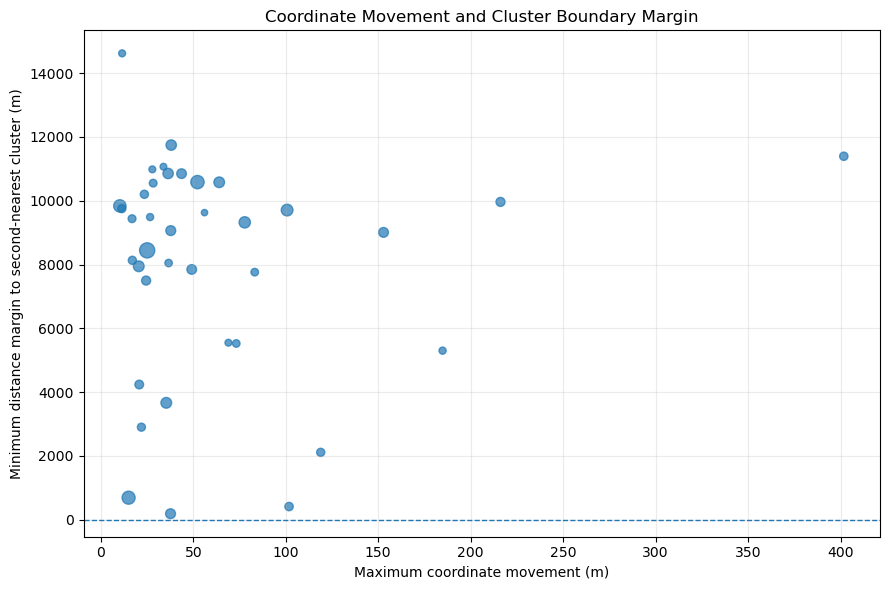

[좌표 이동 대여소 군집 안정성 결과]
10m 이상 좌표 이동 대여소: 38개
첫 좌표·두 번째 좌표 군집 변경: 0개
첫 좌표·최신 좌표 군집 변경: 0개
세 좌표 중 하나라도 군집 변경: 0개
군집 변경 대여소 이용건수: 0건
군집 변경 대여소 전체 수요 비중: 0.000000%
최신 좌표·현재 군집 매핑 불일치: 0개
최소 군집 경계 여유 거리: 183.82m
최소 군집 경계 여유 대여소: 367
최종 안정성 판정: STABLE

[좌표 이동 군집 안정성 요약]


,summary_item,value
0,전체 공식 대여소,2865
1,10m 이상 좌표 이동 대여소,38
2,10m 이상 이동 대여소 이용건수,1176006
3,10m 이상 이동 대여소 수요 비중,1.325691
4,첫 좌표·두 번째 좌표 군집 변경 대여소,0
5,첫 좌표·최신 좌표 군집 변경 대여소,0
6,세 좌표 중 하나라도 군집이 다른 대여소,0
7,군집 변경 대여소 이용건수,0
8,군집 변경 대여소 전체 수요 비중,0.0
9,최신 좌표와 현재 군집 매핑 불일치,0



[군집 경계에 가까운 대여소]


,station_id,latest_station_name,district,max_distance_m,first_pair_cluster_id,second_pair_cluster_id,latest_cluster_id,minimum_cluster_margin_m,rental_count,any_coordinate_cluster_changed
18,367,독립문역 3-1번출구,종로구,37.679621,0,0,0,183.815639,36424.0,False
5,594,중랑물재생센터(서울새활용플라자),성동구,101.772084,2,2,2,408.487493,19746.0,False
34,668,서울축산농협(장안지점),동대문구,14.996535,1,1,1,686.093610,81427.0,False
4,4107,장안동근린공원 입구,동대문구,118.895102,1,1,1,2108.561113,17288.0,False
29,351,청운초교 앞 삼거리,종로구,21.926266,1,1,1,2898.291712,16262.0,False
21,657,동대문롯데캐슬아파트 앞,동대문구,35.380002,1,1,1,3661.703266,47402.0,False
30,4803,상봉2동 주민센터 앞,중랑구,20.756928,1,1,1,4235.316204,22873.0,False
2,3652,한영외국어고등학교,강동구,184.798608,2,2,2,5298.775413,7917.0,False
9,2520,서초1교 (진흥아파트 방면),서초구,73.223700,2,2,2,5523.549703,11296.0,False
10,992,북한산입구 정류장,은평구,68.972198,1,1,1,5547.284986,5029.0,False



[군집이 변경된 대여소]
좌표 이동으로 군집이 변경된 대여소가 없다.

[저장 파일]
outputs\metrics\station_coordinate_cluster_stability.csv
outputs\metrics\station_coordinate_cluster_stability_summary.csv
outputs\metrics\station_coordinate_cluster_changed_stations.csv
outputs\figures\station_coordinate_movement_cluster_margin.png


In [8]:
# 1. 좌표 이동 감사 데이터를 정리한다.

MEANINGFUL_MOVEMENT_THRESHOLD_M = 10.0


coordinate_movement_audit = pd.read_csv(
    COORDINATE_MOVEMENT_AUDIT_PATH,
    encoding="utf-8-sig",
    dtype={
        "station_id": "string",
        "latest_station_name": "string",
    },
)


numeric_columns = [
    "snapshot_count",
    "coordinate_count",
    "max_distance_m",
    "latest_latitude",
    "latest_longitude",
    "first_pair_latitude",
    "first_pair_longitude",
    "second_pair_latitude",
    "second_pair_longitude",
    "active_month_count",
    "rental_count",
]


for column in numeric_columns:
    coordinate_movement_audit[
        column
    ] = pd.to_numeric(
        coordinate_movement_audit[
            column
        ],
        errors="coerce",
    )


coordinate_movement_audit[
    "station_id"
] = (
    coordinate_movement_audit[
        "station_id"
    ]
    .astype("string")
    .str.strip()
)


meaningful_movement_stations = (
    coordinate_movement_audit.loc[
        coordinate_movement_audit[
            "max_distance_m"
        ].ge(
            MEANINGFUL_MOVEMENT_THRESHOLD_M
        )
    ]
    .copy()
    .sort_values(
        "max_distance_m",
        ascending=False,
    )
    .reset_index(drop=True)
)


EXPECTED_MEANINGFUL_MOVEMENT_COUNT = 38


if (
    len(meaningful_movement_stations)
    != EXPECTED_MEANINGFUL_MOVEMENT_COUNT
):
    raise ValueError(
        "10m 이상 좌표 이동 대여소 수가 "
        "예상값과 다르다: "
        f"{len(meaningful_movement_stations):,}개"
    )


required_coordinate_columns = [
    "first_pair_latitude",
    "first_pair_longitude",
    "second_pair_latitude",
    "second_pair_longitude",
    "latest_latitude",
    "latest_longitude",
]


coordinate_missing_count = int(
    meaningful_movement_stations[
        required_coordinate_columns
    ]
    .isna()
    .sum()
    .sum()
)


if coordinate_missing_count != 0:
    raise ValueError(
        "10m 이상 이동 대여소의 좌표에 "
        f"결측치가 존재한다: {coordinate_missing_count:,}개"
    )


# 2. 위도·경도를 기존 평면 좌표계로 변환하는 함수를 정의한다.

def project_latlon_to_meter(
    latitude,
    longitude,
):
    """
    위도·경도를 공간 군집화에서 사용한
    기준점 중심의 미터 단위 평면 좌표로 변환한다.
    """

    latitude_array = np.asarray(
        latitude,
        dtype=float,
    )

    longitude_array = np.asarray(
        longitude,
        dtype=float,
    )

    latitude_radian_array = np.radians(
        latitude_array
    )

    longitude_radian_array = np.radians(
        longitude_array
    )

    x_meter = (
        EARTH_RADIUS_M
        * (
            longitude_radian_array
            - reference_longitude_radian
        )
        * np.cos(
            reference_latitude_radian
        )
    )

    y_meter = (
        EARTH_RADIUS_M
        * (
            latitude_radian_array
            - reference_latitude_radian
        )
    )

    return np.column_stack(
        [
            x_meter,
            y_meter,
        ]
    )


# 3. 가장 가까운 군집과 군집 경계 여유 거리를 계산한다.

def assign_nearest_cluster(
    projected_coordinates,
    cluster_centers,
):
    """
    각 좌표에서 가장 가까운 군집 중심을 찾고,
    최근접 중심과 두 번째 중심까지의 거리를 반환한다.
    """

    coordinate_array = np.asarray(
        projected_coordinates,
        dtype=float,
    )

    center_array = np.asarray(
        cluster_centers,
        dtype=float,
    )

    distance_matrix = np.sqrt(
        np.square(
            coordinate_array[:, None, :]
            - center_array[None, :, :]
        ).sum(axis=2)
    )

    distance_order = np.argsort(
        distance_matrix,
        axis=1,
    )

    nearest_cluster = (
        distance_order[:, 0]
        .astype(int)
    )

    second_nearest_cluster = (
        distance_order[:, 1]
        .astype(int)
    )

    row_index = np.arange(
        len(coordinate_array)
    )

    nearest_distance_m = (
        distance_matrix[
            row_index,
            nearest_cluster,
        ]
    )

    second_nearest_distance_m = (
        distance_matrix[
            row_index,
            second_nearest_cluster,
        ]
    )

    cluster_margin_m = (
        second_nearest_distance_m
        - nearest_distance_m
    )

    return {
        "nearest_cluster": (
            nearest_cluster
        ),
        "second_nearest_cluster": (
            second_nearest_cluster
        ),
        "nearest_distance_m": (
            nearest_distance_m
        ),
        "second_nearest_distance_m": (
            second_nearest_distance_m
        ),
        "cluster_margin_m": (
            cluster_margin_m
        ),
    }


# 4. 세 좌표 유형을 평면 좌표로 변환한다.

first_pair_coordinates = (
    project_latlon_to_meter(
        meaningful_movement_stations[
            "first_pair_latitude"
        ],
        meaningful_movement_stations[
            "first_pair_longitude"
        ],
    )
)


second_pair_coordinates = (
    project_latlon_to_meter(
        meaningful_movement_stations[
            "second_pair_latitude"
        ],
        meaningful_movement_stations[
            "second_pair_longitude"
        ],
    )
)


latest_coordinates = (
    project_latlon_to_meter(
        meaningful_movement_stations[
            "latest_latitude"
        ],
        meaningful_movement_stations[
            "latest_longitude"
        ],
    )
)


first_assignment = assign_nearest_cluster(
    first_pair_coordinates,
    stable_cluster_centers,
)


second_assignment = assign_nearest_cluster(
    second_pair_coordinates,
    stable_cluster_centers,
)


latest_assignment = assign_nearest_cluster(
    latest_coordinates,
    stable_cluster_centers,
)


# 5. 대여소별 군집 안정성 결과를 생성한다.

movement_cluster_stability = (
    meaningful_movement_stations.copy()
)


movement_cluster_stability[
    "first_pair_cluster_id"
] = first_assignment[
    "nearest_cluster"
]


movement_cluster_stability[
    "second_pair_cluster_id"
] = second_assignment[
    "nearest_cluster"
]


movement_cluster_stability[
    "latest_cluster_id"
] = latest_assignment[
    "nearest_cluster"
]


movement_cluster_stability[
    "first_pair_second_nearest_cluster_id"
] = first_assignment[
    "second_nearest_cluster"
]


movement_cluster_stability[
    "second_pair_second_nearest_cluster_id"
] = second_assignment[
    "second_nearest_cluster"
]


movement_cluster_stability[
    "latest_second_nearest_cluster_id"
] = latest_assignment[
    "second_nearest_cluster"
]


movement_cluster_stability[
    "first_pair_nearest_distance_m"
] = first_assignment[
    "nearest_distance_m"
]


movement_cluster_stability[
    "second_pair_nearest_distance_m"
] = second_assignment[
    "nearest_distance_m"
]


movement_cluster_stability[
    "latest_nearest_distance_m"
] = latest_assignment[
    "nearest_distance_m"
]


movement_cluster_stability[
    "first_pair_cluster_margin_m"
] = first_assignment[
    "cluster_margin_m"
]


movement_cluster_stability[
    "second_pair_cluster_margin_m"
] = second_assignment[
    "cluster_margin_m"
]


movement_cluster_stability[
    "latest_cluster_margin_m"
] = latest_assignment[
    "cluster_margin_m"
]


movement_cluster_stability[
    "pair_cluster_changed"
] = (
    movement_cluster_stability[
        "first_pair_cluster_id"
    ]
    .ne(
        movement_cluster_stability[
            "second_pair_cluster_id"
        ]
    )
)


movement_cluster_stability[
    "first_to_latest_cluster_changed"
] = (
    movement_cluster_stability[
        "first_pair_cluster_id"
    ]
    .ne(
        movement_cluster_stability[
            "latest_cluster_id"
        ]
    )
)


movement_cluster_stability[
    "any_coordinate_cluster_changed"
] = (
    movement_cluster_stability[
        [
            "first_pair_cluster_id",
            "second_pair_cluster_id",
            "latest_cluster_id",
        ]
    ]
    .nunique(axis=1)
    .gt(1)
)


movement_cluster_stability[
    "minimum_cluster_margin_m"
] = (
    movement_cluster_stability[
        [
            "first_pair_cluster_margin_m",
            "second_pair_cluster_margin_m",
            "latest_cluster_margin_m",
        ]
    ]
    .min(axis=1)
)


# 6. 현재 대여소 군집 매핑과 최신 좌표 군집을 비교한다.

current_cluster_lookup = (
    station_cluster_map[
        [
            "station_id",
            "cluster_id",
            "cluster_label",
            "district",
        ]
    ]
    .copy()
)


current_cluster_lookup[
    "station_id"
] = (
    current_cluster_lookup[
        "station_id"
    ]
    .astype("string")
    .str.strip()
)


current_cluster_lookup = (
    current_cluster_lookup
    .rename(
        columns={
            "cluster_id": (
                "current_map_cluster_id"
            ),
            "cluster_label": (
                "current_map_cluster_label"
            ),
        }
    )
)


movement_cluster_stability = (
    movement_cluster_stability
    .merge(
        current_cluster_lookup,
        on="station_id",
        how="left",
        validate="one_to_one",
    )
)


movement_cluster_stability[
    "latest_matches_current_map"
] = (
    movement_cluster_stability[
        "latest_cluster_id"
    ]
    .eq(
        movement_cluster_stability[
            "current_map_cluster_id"
        ]
    )
)


movement_cluster_stability[
    "first_pair_cluster_label"
] = (
    movement_cluster_stability[
        "first_pair_cluster_id"
    ].map(
        cluster_label_map
    )
)


movement_cluster_stability[
    "second_pair_cluster_label"
] = (
    movement_cluster_stability[
        "second_pair_cluster_id"
    ].map(
        cluster_label_map
    )
)


movement_cluster_stability[
    "latest_cluster_label"
] = (
    movement_cluster_stability[
        "latest_cluster_id"
    ].map(
        cluster_label_map
    )
)


# 7. 안정성 검증 결과를 계산한다.

pair_cluster_change_count = int(
    movement_cluster_stability[
        "pair_cluster_changed"
    ].sum()
)


first_to_latest_change_count = int(
    movement_cluster_stability[
        "first_to_latest_cluster_changed"
    ].sum()
)


any_cluster_change_count = int(
    movement_cluster_stability[
        "any_coordinate_cluster_changed"
    ].sum()
)


latest_map_mismatch_count = int(
    (
        ~movement_cluster_stability[
            "latest_matches_current_map"
        ]
    ).sum()
)


changed_station_rental_count = int(
    movement_cluster_stability.loc[
        movement_cluster_stability[
            "any_coordinate_cluster_changed"
        ],
        "rental_count",
    ]
    .fillna(0)
    .sum()
)


meaningful_station_rental_count = int(
    movement_cluster_stability[
        "rental_count"
    ]
    .fillna(0)
    .sum()
)


TOTAL_SPATIAL_RENTAL_COUNT = (
    88_708_877
)


changed_station_rental_share_pct = (
    changed_station_rental_count
    / TOTAL_SPATIAL_RENTAL_COUNT
    * 100
)


meaningful_station_rental_share_pct = (
    meaningful_station_rental_count
    / TOTAL_SPATIAL_RENTAL_COUNT
    * 100
)


minimum_margin_station_id = (
    movement_cluster_stability.loc[
        movement_cluster_stability[
            "minimum_cluster_margin_m"
        ].idxmin(),
        "station_id",
    ]
)


minimum_cluster_margin_m = float(
    movement_cluster_stability[
        "minimum_cluster_margin_m"
    ].min()
)


# 8. 검증 조건을 확인한다.

if movement_cluster_stability[
    "current_map_cluster_id"
].isna().any():
    raise ValueError(
        "좌표 이동 대여소 중 현재 군집 매핑과 "
        "결합되지 않은 대여소가 존재한다."
    )


if latest_map_mismatch_count != 0:
    mismatch_sample = (
        movement_cluster_stability.loc[
            ~movement_cluster_stability[
                "latest_matches_current_map"
            ],
            [
                "station_id",
                "latest_station_name",
                "latest_cluster_id",
                "current_map_cluster_id",
            ],
        ]
    )

    print(
        "[최신 좌표 군집과 현재 매핑 불일치]"
    )

    display(
        mismatch_sample
    )

    raise ValueError(
        "최신 좌표를 이용해 계산한 군집과 "
        "station_cluster_map의 군집이 일치하지 않는다."
    )


# 9. 군집 안정성 요약표를 생성한다.

coordinate_cluster_stability_summary = pd.DataFrame(
    {
        "summary_item": [
            "전체 공식 대여소",
            "10m 이상 좌표 이동 대여소",
            "10m 이상 이동 대여소 이용건수",
            "10m 이상 이동 대여소 수요 비중",
            "첫 좌표·두 번째 좌표 군집 변경 대여소",
            "첫 좌표·최신 좌표 군집 변경 대여소",
            "세 좌표 중 하나라도 군집이 다른 대여소",
            "군집 변경 대여소 이용건수",
            "군집 변경 대여소 전체 수요 비중",
            "최신 좌표와 현재 군집 매핑 불일치",
            "최소 군집 경계 여유 거리",
            "최소 군집 경계 여유 대여소",
            "최종 좌표 군집 안정성 판정",
        ],
        "value": [
            len(
                coordinate_movement_audit
            ),
            len(
                movement_cluster_stability
            ),
            meaningful_station_rental_count,
            meaningful_station_rental_share_pct,
            pair_cluster_change_count,
            first_to_latest_change_count,
            any_cluster_change_count,
            changed_station_rental_count,
            changed_station_rental_share_pct,
            latest_map_mismatch_count,
            minimum_cluster_margin_m,
            minimum_margin_station_id,
            (
                "STABLE"
                if any_cluster_change_count == 0
                else "SENSITIVE"
            ),
        ],
    }
)


# 10. 분석 결과를 저장한다.

coordinate_stability_detail_path = (
    METRICS_DIR
    / "station_coordinate_cluster_stability.csv"
)


coordinate_stability_summary_path = (
    METRICS_DIR
    / "station_coordinate_cluster_stability_summary.csv"
)


coordinate_changed_station_path = (
    METRICS_DIR
    / "station_coordinate_cluster_changed_stations.csv"
)


movement_cluster_stability.to_csv(
    coordinate_stability_detail_path,
    index=False,
    encoding="utf-8-sig",
)


coordinate_cluster_stability_summary.to_csv(
    coordinate_stability_summary_path,
    index=False,
    encoding="utf-8-sig",
)


changed_cluster_stations = (
    movement_cluster_stability.loc[
        movement_cluster_stability[
            "any_coordinate_cluster_changed"
        ]
    ]
    .copy()
    .sort_values(
        [
            "rental_count",
            "max_distance_m",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


changed_cluster_stations.to_csv(
    coordinate_changed_station_path,
    index=False,
    encoding="utf-8-sig",
)


# 11. 좌표 이동 거리와 군집 경계 여유를 시각화한다.

coordinate_stability_figure_path = (
    FIGURES_DIR
    / "station_coordinate_movement_cluster_margin.png"
)


plt.figure(
    figsize=(9, 6)
)


plt.scatter(
    movement_cluster_stability[
        "max_distance_m"
    ],
    movement_cluster_stability[
        "minimum_cluster_margin_m"
    ],
    s=(
        20
        + movement_cluster_stability[
            "rental_count"
        ]
        .fillna(0)
        .div(
            movement_cluster_stability[
                "rental_count"
            ]
            .fillna(0)
            .max()
        )
        .mul(100)
    ),
    alpha=0.7,
)


plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
)


plt.xlabel(
    "Maximum coordinate movement (m)"
)


plt.ylabel(
    "Minimum distance margin to second-nearest cluster (m)"
)


plt.title(
    "Coordinate Movement and Cluster Boundary Margin"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    coordinate_stability_figure_path,
    dpi=200,
    bbox_inches="tight",
)


plt.show()


# 12. 결과를 출력한다.

print("[좌표 이동 대여소 군집 안정성 결과]")
print(
    f"10m 이상 좌표 이동 대여소: "
    f"{len(movement_cluster_stability):,}개"
)
print(
    f"첫 좌표·두 번째 좌표 군집 변경: "
    f"{pair_cluster_change_count:,}개"
)
print(
    f"첫 좌표·최신 좌표 군집 변경: "
    f"{first_to_latest_change_count:,}개"
)
print(
    f"세 좌표 중 하나라도 군집 변경: "
    f"{any_cluster_change_count:,}개"
)
print(
    f"군집 변경 대여소 이용건수: "
    f"{changed_station_rental_count:,}건"
)
print(
    "군집 변경 대여소 전체 수요 비중: "
    f"{changed_station_rental_share_pct:.6f}%"
)
print(
    f"최신 좌표·현재 군집 매핑 불일치: "
    f"{latest_map_mismatch_count:,}개"
)
print(
    "최소 군집 경계 여유 거리: "
    f"{minimum_cluster_margin_m:,.2f}m"
)
print(
    "최소 군집 경계 여유 대여소: "
    f"{minimum_margin_station_id}"
)
print(
    "최종 안정성 판정: "
    f"{'STABLE' if any_cluster_change_count == 0 else 'SENSITIVE'}"
)


print("\n[좌표 이동 군집 안정성 요약]")
display(
    coordinate_cluster_stability_summary
)


print("\n[군집 경계에 가까운 대여소]")
display(
    movement_cluster_stability[
        [
            "station_id",
            "latest_station_name",
            "district",
            "max_distance_m",
            "first_pair_cluster_id",
            "second_pair_cluster_id",
            "latest_cluster_id",
            "minimum_cluster_margin_m",
            "rental_count",
            "any_coordinate_cluster_changed",
        ]
    ]
    .sort_values(
        "minimum_cluster_margin_m"
    )
    .head(15)
)


print("\n[군집이 변경된 대여소]")


if changed_cluster_stations.empty:
    print(
        "좌표 이동으로 군집이 변경된 "
        "대여소가 없다."
    )

else:
    display(
        changed_cluster_stations[
            [
                "station_id",
                "latest_station_name",
                "district",
                "max_distance_m",
                "first_pair_snapshot",
                "second_pair_snapshot",
                "first_pair_cluster_id",
                "second_pair_cluster_id",
                "latest_cluster_id",
                "minimum_cluster_margin_m",
                "rental_count",
            ]
        ]
    )


print("\n[저장 파일]")
print(
    coordinate_stability_detail_path.relative_to(
        ROOT
    )
)
print(
    coordinate_stability_summary_path.relative_to(
        ROOT
    )
)
print(
    coordinate_changed_station_path.relative_to(
        ROOT
    )
)
print(
    coordinate_stability_figure_path.relative_to(
        ROOT
    )
)

## 9. 공간 군집화 최종 검증 및 산출물 정리

공간 군집화 과정에서 생성한 핵심 산출물을 다시 불러와 최종 무결성을 검증한다.

최종 검증 항목은 다음과 같다.

- 군집 수 후보 2개부터 10개까지 모두 평가되었는지 확인한다.
- Silhouette Score 기준 최적 군집 수가 3개인지 확인한다.
- 대여소 2,847개가 중복과 누락 없이 3개 군집에 배정되었는지 확인한다.
- 군집 번호가 군집 중심의 서쪽에서 동쪽 순서로 정렬되었는지 확인한다.
- 대여소 군집화 전후의 이용건수 88,708,877건이 보존되었는지 확인한다.
- 군집별 시간대 수요가 2023년 1월 1일부터 2024년 12월 31일까지 완전한 시간축을 갖는지 확인한다.
- `datetime × cluster_id` 조합에 중복이나 결측이 없는지 확인한다.
- 좌표가 10m 이상 이동한 38개 대여소의 군집이 모두 유지되었는지 확인한다.
- 분석에 필요한 표, 지표 및 시각화 파일이 정상적으로 저장되었는지 확인한다.

최종 검증 결과와 분석 요약은 별도의 CSV, JSON 및 Markdown 보고서로 저장한다. 하나라도 검증에 실패하면 후속 모델링 단계로 진행하지 않는다.

In [9]:
# 1. 최종 검증 기준값을 설정한다.

EXPECTED_STATION_COUNT = 2_847
EXPECTED_CLUSTER_COUNT = 3

EXPECTED_HOUR_COUNT_PER_CLUSTER = 17_544
EXPECTED_CLUSTER_HOURLY_ROW_COUNT = 52_632

EXPECTED_TOTAL_RENTAL_COUNT = 88_708_877
EXPECTED_MEANINGFUL_MOVEMENT_COUNT = 38

EXPECTED_START_DATETIME = pd.Timestamp(
    "2023-01-01 00:00:00"
)

EXPECTED_END_DATETIME = pd.Timestamp(
    "2024-12-31 23:00:00"
)

EXPECTED_CLUSTER_IDS = {
    0,
    1,
    2,
}

EXPECTED_K_CANDIDATES = list(
    range(2, 11)
)


# 2. 최종 검증 대상 파일 경로를 설정한다.

final_artifact_paths = {
    "대여소 군집 매핑": (
        PROCESSED_DIR
        / "station_cluster_map.csv"
    ),
    "군집별 시간대 수요": (
        PROCESSED_DIR
        / "cluster_hourly_demand.csv"
    ),
    "군집 수 후보 평가": (
        METRICS_DIR
        / "spatial_cluster_candidate_metrics.csv"
    ),
    "군집별 요약": (
        METRICS_DIR
        / "spatial_cluster_summary.csv"
    ),
    "군집별 자치구 구성": (
        METRICS_DIR
        / "spatial_cluster_district_composition.csv"
    ),
    "군집 중심 좌표": (
        METRICS_DIR
        / "spatial_cluster_centroids.csv"
    ),
    "월별 군집 수요 집계 요약": (
        METRICS_DIR
        / "cluster_hourly_demand_summary.csv"
    ),
    "시계열 완전성": (
        METRICS_DIR
        / "cluster_time_series_completeness.csv"
    ),
    "군집 수요 기술통계": (
        METRICS_DIR
        / "cluster_demand_descriptive_stats.csv"
    ),
    "시간대별 수요 프로파일": (
        METRICS_DIR
        / "cluster_hourly_profile.csv"
    ),
    "요일별 수요 프로파일": (
        METRICS_DIR
        / "cluster_weekday_profile.csv"
    ),
    "월별 수요 프로파일": (
        METRICS_DIR
        / "cluster_monthly_profile.csv"
    ),
    "일별 군집 수요": (
        METRICS_DIR
        / "cluster_daily_demand.csv"
    ),
    "시차 자기상관": (
        METRICS_DIR
        / "cluster_autocorrelation_summary.csv"
    ),
    "좌표 이동 군집 안정성 상세": (
        METRICS_DIR
        / "station_coordinate_cluster_stability.csv"
    ),
    "좌표 이동 군집 안정성 요약": (
        METRICS_DIR
        / "station_coordinate_cluster_stability_summary.csv"
    ),
    "좌표 이동 군집 변경 대여소": (
        METRICS_DIR
        / "station_coordinate_cluster_changed_stations.csv"
    ),
    "군집 수별 Inertia 그래프": (
        FIGURES_DIR
        / "spatial_cluster_inertia_by_k.png"
    ),
    "군집 수별 Silhouette 그래프": (
        FIGURES_DIR
        / "spatial_cluster_silhouette_by_k.png"
    ),
    "최종 공간 군집 지도": (
        FIGURES_DIR
        / "spatial_station_clusters_k3.png"
    ),
    "군집별 일별 수요 그래프": (
        FIGURES_DIR
        / "cluster_daily_demand_timeseries.png"
    ),
    "군집별 시간대 수요 그래프": (
        FIGURES_DIR
        / "cluster_hourly_demand_profile.png"
    ),
    "군집별 요일 수요 그래프": (
        FIGURES_DIR
        / "cluster_weekday_demand_profile.png"
    ),
    "군집별 월간 수요 그래프": (
        FIGURES_DIR
        / "cluster_monthly_mean_demand.png"
    ),
    "좌표 이동 안정성 그래프": (
        FIGURES_DIR
        / "station_coordinate_movement_cluster_margin.png"
    ),
}


FINAL_VALIDATION_PATH = (
    METRICS_DIR
    / "spatial_clustering_final_validation.csv"
)

FINAL_SUMMARY_PATH = (
    METRICS_DIR
    / "spatial_clustering_final_summary.csv"
)

FINAL_MANIFEST_PATH = (
    REPORTS_DIR
    / "spatial_clustering_manifest.json"
)

FINAL_REPORT_PATH = (
    REPORTS_DIR
    / "spatial_clustering_final_report.md"
)


# 3. 검증 결과 기록 함수를 정의한다.

validation_records = []


def add_validation(
    validation_item,
    passed,
    actual,
    expected,
    detail="",
):
    """공간 군집화 최종 검증 결과를 기록한다."""

    validation_records.append(
        {
            "validation_item": (
                validation_item
            ),
            "passed": bool(passed),
            "actual": str(actual),
            "expected": str(expected),
            "detail": detail,
        }
    )


def parse_boolean_series(
    series,
):
    """CSV의 불리언 값을 안전하게 변환한다."""

    if pd.api.types.is_bool_dtype(
        series
    ):
        return (
            series
            .fillna(False)
            .astype(bool)
        )

    normalized = (
        series
        .astype("string")
        .str.strip()
        .str.lower()
    )

    return (
        normalized
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
        .fillna(False)
        .astype(bool)
    )


# 4. 필수 산출물 존재 여부와 파일 크기를 확인한다.

artifact_inventory_records = []


for artifact_name, artifact_path in (
    final_artifact_paths.items()
):
    exists = artifact_path.exists()

    file_size_bytes = (
        artifact_path.stat().st_size
        if exists
        else 0
    )

    artifact_inventory_records.append(
        {
            "artifact_name": (
                artifact_name
            ),
            "relative_path": (
                str(
                    artifact_path.relative_to(
                        ROOT
                    )
                )
            ),
            "exists": exists,
            "file_size_bytes": (
                file_size_bytes
            ),
            "file_size_mb": (
                round(
                    file_size_bytes
                    / (1024 ** 2),
                    3,
                )
                if exists
                else pd.NA
            ),
        }
    )

    add_validation(
        validation_item=(
            f"필수 산출물 존재: "
            f"{artifact_name}"
        ),
        passed=exists,
        actual=exists,
        expected=True,
        detail=str(
            artifact_path.relative_to(
                ROOT
            )
        ),
    )

    add_validation(
        validation_item=(
            f"필수 산출물 파일 크기: "
            f"{artifact_name}"
        ),
        passed=(
            exists
            and file_size_bytes > 0
        ),
        actual=file_size_bytes,
        expected="0보다 큼",
        detail=str(
            artifact_path.relative_to(
                ROOT
            )
        ),
    )


artifact_inventory = pd.DataFrame(
    artifact_inventory_records
)


missing_artifacts = (
    artifact_inventory.loc[
        ~artifact_inventory[
            "exists"
        ],
        "artifact_name",
    ]
    .tolist()
)


empty_artifacts = (
    artifact_inventory.loc[
        artifact_inventory[
            "file_size_bytes"
        ].eq(0),
        "artifact_name",
    ]
    .tolist()
)


print("[공간 군집화 산출물 목록]")
display(
    artifact_inventory
)


if missing_artifacts:
    raise FileNotFoundError(
        "필수 공간 군집화 산출물이 존재하지 않는다: "
        f"{missing_artifacts}"
    )


if empty_artifacts:
    raise ValueError(
        "크기가 0인 공간 군집화 산출물이 존재한다: "
        f"{empty_artifacts}"
    )


# 5. 핵심 산출물을 다시 불러온다.

station_cluster_map_final = pd.read_csv(
    final_artifact_paths[
        "대여소 군집 매핑"
    ],
    encoding="utf-8-sig",
    dtype={
        "station_id": "string",
        "cluster_id": "Int64",
        "cluster_label": "string",
    },
)


cluster_hourly_demand_final = pd.read_csv(
    final_artifact_paths[
        "군집별 시간대 수요"
    ],
    encoding="utf-8-sig",
    dtype={
        "cluster_id": "Int64",
        "cluster_label": "string",
    },
    parse_dates=[
        "datetime",
    ],
)


cluster_candidate_metrics_final = pd.read_csv(
    final_artifact_paths[
        "군집 수 후보 평가"
    ],
    encoding="utf-8-sig",
)


cluster_summary_final = pd.read_csv(
    final_artifact_paths[
        "군집별 요약"
    ],
    encoding="utf-8-sig",
)


cluster_centroids_final = pd.read_csv(
    final_artifact_paths[
        "군집 중심 좌표"
    ],
    encoding="utf-8-sig",
)


cluster_hourly_monthly_summary_final = (
    pd.read_csv(
        final_artifact_paths[
            "월별 군집 수요 집계 요약"
        ],
        encoding="utf-8-sig",
        dtype={
            "year_month": "string",
        },
    )
)


cluster_time_completeness_final = (
    pd.read_csv(
        final_artifact_paths[
            "시계열 완전성"
        ],
        encoding="utf-8-sig",
        dtype={
            "cluster_id": "Int64",
            "cluster_label": "string",
        },
    )
)


coordinate_stability_summary_final = (
    pd.read_csv(
        final_artifact_paths[
            "좌표 이동 군집 안정성 요약"
        ],
        encoding="utf-8-sig",
        dtype="string",
    )
)


coordinate_changed_stations_final = (
    pd.read_csv(
        final_artifact_paths[
            "좌표 이동 군집 변경 대여소"
        ],
        encoding="utf-8-sig",
    )
)


# 6. 숫자형 컬럼을 정리한다.

station_map_numeric_columns = [
    "latitude",
    "longitude",
    "x_meter",
    "y_meter",
    "cluster_id",
    "distance_to_centroid_m",
    "rental_count",
]


for column in station_map_numeric_columns:
    station_cluster_map_final[
        column
    ] = pd.to_numeric(
        station_cluster_map_final[
            column
        ],
        errors="coerce",
    )


cluster_hourly_demand_final[
    "rental_count"
] = pd.to_numeric(
    cluster_hourly_demand_final[
        "rental_count"
    ],
    errors="coerce",
)


candidate_numeric_columns = [
    "n_clusters",
    "inertia",
    "silhouette_score",
    "calinski_harabasz_score",
    "davies_bouldin_score",
]


for column in candidate_numeric_columns:
    cluster_candidate_metrics_final[
        column
    ] = pd.to_numeric(
        cluster_candidate_metrics_final[
            column
        ],
        errors="coerce",
    )


cluster_summary_numeric_columns = [
    "cluster_id",
    "station_count",
    "total_rental_count",
    "station_share_pct",
    "rental_share_pct",
]


for column in cluster_summary_numeric_columns:
    cluster_summary_final[
        column
    ] = pd.to_numeric(
        cluster_summary_final[
            column
        ],
        errors="coerce",
    )


centroid_numeric_columns = [
    "cluster_id",
    "centroid_x_meter",
    "centroid_y_meter",
    "centroid_latitude",
    "centroid_longitude",
]


for column in centroid_numeric_columns:
    cluster_centroids_final[
        column
    ] = pd.to_numeric(
        cluster_centroids_final[
            column
        ],
        errors="coerce",
    )


monthly_summary_numeric_columns = [
    "input_row_count",
    "output_row_count",
    "input_station_count",
    "cluster_count",
    "input_rental_count",
    "output_rental_count",
]


for column in monthly_summary_numeric_columns:
    cluster_hourly_monthly_summary_final[
        column
    ] = pd.to_numeric(
        cluster_hourly_monthly_summary_final[
            column
        ],
        errors="coerce",
    )


cluster_time_completeness_final[
    "is_complete"
] = parse_boolean_series(
    cluster_time_completeness_final[
        "is_complete"
    ]
)


# 7. 군집 수 후보 평가 결과를 검증한다.

observed_k_candidates = (
    cluster_candidate_metrics_final[
        "n_clusters"
    ]
    .dropna()
    .astype(int)
    .sort_values()
    .tolist()
)


best_silhouette_row = (
    cluster_candidate_metrics_final.loc[
        cluster_candidate_metrics_final[
            "silhouette_score"
        ].idxmax()
    ]
)


best_silhouette_k = int(
    best_silhouette_row[
        "n_clusters"
    ]
)


best_silhouette_score = float(
    best_silhouette_row[
        "silhouette_score"
    ]
)


selected_k_row = (
    cluster_candidate_metrics_final.loc[
        cluster_candidate_metrics_final[
            "n_clusters"
        ].eq(
            EXPECTED_CLUSTER_COUNT
        )
    ]
    .iloc[0]
)


selected_calinski_score = float(
    selected_k_row[
        "calinski_harabasz_score"
    ]
)


selected_davies_score = float(
    selected_k_row[
        "davies_bouldin_score"
    ]
)


add_validation(
    validation_item=(
        "군집 수 후보 목록"
    ),
    passed=(
        observed_k_candidates
        == EXPECTED_K_CANDIDATES
    ),
    actual=observed_k_candidates,
    expected=EXPECTED_K_CANDIDATES,
)


add_validation(
    validation_item=(
        "Silhouette Score 기준 최적 K"
    ),
    passed=(
        best_silhouette_k
        == EXPECTED_CLUSTER_COUNT
    ),
    actual=best_silhouette_k,
    expected=EXPECTED_CLUSTER_COUNT,
)


# 8. 대여소 군집 매핑을 검증한다.

station_map_cluster_ids = set(
    station_cluster_map_final[
        "cluster_id"
    ]
    .dropna()
    .astype(int)
    .unique()
)


station_map_core_missing_count = int(
    station_cluster_map_final[
        [
            "station_id",
            "cluster_id",
            "cluster_label",
            "latitude",
            "longitude",
            "x_meter",
            "y_meter",
            "distance_to_centroid_m",
            "rental_count",
        ]
    ]
    .isna()
    .sum()
    .sum()
)


station_map_duplicate_count = int(
    station_cluster_map_final[
        "station_id"
    ]
    .duplicated()
    .sum()
)


station_map_total_rental_count = int(
    station_cluster_map_final[
        "rental_count"
    ]
    .fillna(0)
    .sum()
)


negative_centroid_distance_count = int(
    station_cluster_map_final[
        "distance_to_centroid_m"
    ]
    .lt(0)
    .fillna(False)
    .sum()
)


add_validation(
    validation_item=(
        "대여소 군집 매핑 행 수"
    ),
    passed=(
        len(
            station_cluster_map_final
        )
        == EXPECTED_STATION_COUNT
    ),
    actual=len(
        station_cluster_map_final
    ),
    expected=EXPECTED_STATION_COUNT,
)


add_validation(
    validation_item=(
        "대여소 군집 매핑 고유 ID 수"
    ),
    passed=(
        station_cluster_map_final[
            "station_id"
        ].nunique()
        == EXPECTED_STATION_COUNT
    ),
    actual=(
        station_cluster_map_final[
            "station_id"
        ].nunique()
    ),
    expected=EXPECTED_STATION_COUNT,
)


add_validation(
    validation_item=(
        "대여소 군집 매핑 ID 중복"
    ),
    passed=(
        station_map_duplicate_count == 0
    ),
    actual=station_map_duplicate_count,
    expected=0,
)


add_validation(
    validation_item=(
        "대여소 군집 매핑 핵심 변수 결측"
    ),
    passed=(
        station_map_core_missing_count
        == 0
    ),
    actual=(
        station_map_core_missing_count
    ),
    expected=0,
)


add_validation(
    validation_item=(
        "대여소 군집 번호 집합"
    ),
    passed=(
        station_map_cluster_ids
        == EXPECTED_CLUSTER_IDS
    ),
    actual=sorted(
        station_map_cluster_ids
    ),
    expected=sorted(
        EXPECTED_CLUSTER_IDS
    ),
)


add_validation(
    validation_item=(
        "대여소 군집 매핑 이용건수"
    ),
    passed=(
        station_map_total_rental_count
        == EXPECTED_TOTAL_RENTAL_COUNT
    ),
    actual=(
        station_map_total_rental_count
    ),
    expected=(
        EXPECTED_TOTAL_RENTAL_COUNT
    ),
)


add_validation(
    validation_item=(
        "군집 중심까지 음수 거리"
    ),
    passed=(
        negative_centroid_distance_count
        == 0
    ),
    actual=(
        negative_centroid_distance_count
    ),
    expected=0,
)


# 9. 군집 요약과 군집 중심 순서를 검증한다.

cluster_summary_station_count = int(
    cluster_summary_final[
        "station_count"
    ]
    .fillna(0)
    .sum()
)


cluster_summary_rental_count = int(
    cluster_summary_final[
        "total_rental_count"
    ]
    .fillna(0)
    .sum()
)


station_share_sum = float(
    cluster_summary_final[
        "station_share_pct"
    ]
    .fillna(0)
    .sum()
)


rental_share_sum = float(
    cluster_summary_final[
        "rental_share_pct"
    ]
    .fillna(0)
    .sum()
)


cluster_centroids_sorted = (
    cluster_centroids_final
    .sort_values(
        "cluster_id"
    )
    .reset_index(drop=True)
)


centroid_x_is_increasing = bool(
    cluster_centroids_sorted[
        "centroid_x_meter"
    ].is_monotonic_increasing
)


centroid_longitude_is_increasing = bool(
    cluster_centroids_sorted[
        "centroid_longitude"
    ].is_monotonic_increasing
)


add_validation(
    validation_item=(
        "군집 요약 행 수"
    ),
    passed=(
        len(cluster_summary_final)
        == EXPECTED_CLUSTER_COUNT
    ),
    actual=len(
        cluster_summary_final
    ),
    expected=EXPECTED_CLUSTER_COUNT,
)


add_validation(
    validation_item=(
        "군집별 대여소 수 합계"
    ),
    passed=(
        cluster_summary_station_count
        == EXPECTED_STATION_COUNT
    ),
    actual=(
        cluster_summary_station_count
    ),
    expected=EXPECTED_STATION_COUNT,
)


add_validation(
    validation_item=(
        "군집별 이용건수 합계"
    ),
    passed=(
        cluster_summary_rental_count
        == EXPECTED_TOTAL_RENTAL_COUNT
    ),
    actual=(
        cluster_summary_rental_count
    ),
    expected=(
        EXPECTED_TOTAL_RENTAL_COUNT
    ),
)


add_validation(
    validation_item=(
        "군집별 대여소 비중 합계"
    ),
    passed=np.isclose(
        station_share_sum,
        100.0,
        atol=1e-6,
    ),
    actual=station_share_sum,
    expected=100.0,
)


add_validation(
    validation_item=(
        "군집별 수요 비중 합계"
    ),
    passed=np.isclose(
        rental_share_sum,
        100.0,
        atol=1e-6,
    ),
    actual=rental_share_sum,
    expected=100.0,
)


add_validation(
    validation_item=(
        "군집 중심 개수"
    ),
    passed=(
        len(cluster_centroids_final)
        == EXPECTED_CLUSTER_COUNT
    ),
    actual=len(
        cluster_centroids_final
    ),
    expected=EXPECTED_CLUSTER_COUNT,
)


add_validation(
    validation_item=(
        "군집 중심 X좌표 서쪽→동쪽 정렬"
    ),
    passed=centroid_x_is_increasing,
    actual=(
        cluster_centroids_sorted[
            "centroid_x_meter"
        ].round(3).tolist()
    ),
    expected="오름차순",
)


add_validation(
    validation_item=(
        "군집 중심 경도 서쪽→동쪽 정렬"
    ),
    passed=(
        centroid_longitude_is_increasing
    ),
    actual=(
        cluster_centroids_sorted[
            "centroid_longitude"
        ].round(6).tolist()
    ),
    expected="오름차순",
)


# 10. 군집별 시간대 수요를 검증한다.

hourly_duplicate_key_count = int(
    cluster_hourly_demand_final.duplicated(
        subset=[
            "datetime",
            "cluster_id",
        ]
    ).sum()
)


hourly_core_missing_count = int(
    cluster_hourly_demand_final[
        [
            "datetime",
            "cluster_id",
            "cluster_label",
            "rental_count",
        ]
    ]
    .isna()
    .sum()
    .sum()
)


hourly_negative_count = int(
    cluster_hourly_demand_final[
        "rental_count"
    ]
    .lt(0)
    .fillna(False)
    .sum()
)


hourly_non_integer_count = int(
    (
        cluster_hourly_demand_final[
            "rental_count"
        ].notna()
        & ~cluster_hourly_demand_final[
            "rental_count"
        ].mod(1).eq(0)
    ).sum()
)


hourly_cluster_ids = set(
    cluster_hourly_demand_final[
        "cluster_id"
    ]
    .dropna()
    .astype(int)
    .unique()
)


hourly_total_rental_count = int(
    cluster_hourly_demand_final[
        "rental_count"
    ]
    .fillna(0)
    .sum()
)


hourly_row_count_by_cluster = (
    cluster_hourly_demand_final
    .groupby(
        "cluster_id"
    )
    .size()
)


hourly_period_count = int(
    cluster_hourly_demand_final[
        "datetime"
    ]
    .dt.to_period("M")
    .nunique()
)


add_validation(
    validation_item=(
        "군집별 시간대 수요 행 수"
    ),
    passed=(
        len(
            cluster_hourly_demand_final
        )
        == EXPECTED_CLUSTER_HOURLY_ROW_COUNT
    ),
    actual=len(
        cluster_hourly_demand_final
    ),
    expected=(
        EXPECTED_CLUSTER_HOURLY_ROW_COUNT
    ),
)


add_validation(
    validation_item=(
        "군집별 시간대 수요 중복 키"
    ),
    passed=(
        hourly_duplicate_key_count == 0
    ),
    actual=(
        hourly_duplicate_key_count
    ),
    expected=0,
)


add_validation(
    validation_item=(
        "군집별 시간대 수요 핵심 변수 결측"
    ),
    passed=(
        hourly_core_missing_count == 0
    ),
    actual=(
        hourly_core_missing_count
    ),
    expected=0,
)


add_validation(
    validation_item=(
        "군집별 시간대 수요 음수 이용건수"
    ),
    passed=(
        hourly_negative_count == 0
    ),
    actual=hourly_negative_count,
    expected=0,
)


add_validation(
    validation_item=(
        "군집별 시간대 수요 비정수 이용건수"
    ),
    passed=(
        hourly_non_integer_count == 0
    ),
    actual=hourly_non_integer_count,
    expected=0,
)


add_validation(
    validation_item=(
        "군집별 시간대 수요 군집 번호"
    ),
    passed=(
        hourly_cluster_ids
        == EXPECTED_CLUSTER_IDS
    ),
    actual=sorted(
        hourly_cluster_ids
    ),
    expected=sorted(
        EXPECTED_CLUSTER_IDS
    ),
)


add_validation(
    validation_item=(
        "군집별 시간대 수요 전체 이용건수"
    ),
    passed=(
        hourly_total_rental_count
        == EXPECTED_TOTAL_RENTAL_COUNT
    ),
    actual=(
        hourly_total_rental_count
    ),
    expected=(
        EXPECTED_TOTAL_RENTAL_COUNT
    ),
)


add_validation(
    validation_item=(
        "군집별 시간대 수요 시작 시각"
    ),
    passed=(
        cluster_hourly_demand_final[
            "datetime"
        ].min()
        == EXPECTED_START_DATETIME
    ),
    actual=(
        cluster_hourly_demand_final[
            "datetime"
        ].min()
    ),
    expected=EXPECTED_START_DATETIME,
)


add_validation(
    validation_item=(
        "군집별 시간대 수요 종료 시각"
    ),
    passed=(
        cluster_hourly_demand_final[
            "datetime"
        ].max()
        == EXPECTED_END_DATETIME
    ),
    actual=(
        cluster_hourly_demand_final[
            "datetime"
        ].max()
    ),
    expected=EXPECTED_END_DATETIME,
)


add_validation(
    validation_item=(
        "군집별 시간대 수요 관측월 수"
    ),
    passed=(
        hourly_period_count == 24
    ),
    actual=hourly_period_count,
    expected=24,
)


add_validation(
    validation_item=(
        "군집별 관측 시간 수"
    ),
    passed=(
        hourly_row_count_by_cluster
        .eq(
            EXPECTED_HOUR_COUNT_PER_CLUSTER
        )
        .all()
    ),
    actual=(
        hourly_row_count_by_cluster
        .astype(int)
        .to_dict()
    ),
    expected={
        0: EXPECTED_HOUR_COUNT_PER_CLUSTER,
        1: EXPECTED_HOUR_COUNT_PER_CLUSTER,
        2: EXPECTED_HOUR_COUNT_PER_CLUSTER,
    },
)


# 11. 월별 수요 집계 보존과 시간축 완전성을 검증한다.

monthly_input_output_match = bool(
    cluster_hourly_monthly_summary_final[
        "input_rental_count"
    ]
    .eq(
        cluster_hourly_monthly_summary_final[
            "output_rental_count"
        ]
    )
    .all()
)


time_series_all_complete = bool(
    cluster_time_completeness_final[
        "is_complete"
    ].all()
)


add_validation(
    validation_item=(
        "월별 군집 수요 집계 기록 수"
    ),
    passed=(
        len(
            cluster_hourly_monthly_summary_final
        )
        == 24
    ),
    actual=len(
        cluster_hourly_monthly_summary_final
    ),
    expected=24,
)


add_validation(
    validation_item=(
        "월별 군집 수요 집계 전후 수요 보존"
    ),
    passed=monthly_input_output_match,
    actual=monthly_input_output_match,
    expected=True,
)


add_validation(
    validation_item=(
        "군집별 시간축 완전성"
    ),
    passed=time_series_all_complete,
    actual=(
        cluster_time_completeness_final[
            "is_complete"
        ].tolist()
    ),
    expected=[
        True,
        True,
        True,
    ],
)


# 12. 좌표 이동 군집 안정성을 검증한다.

stability_summary_dict = dict(
    zip(
        coordinate_stability_summary_final[
            "summary_item"
        ],
        coordinate_stability_summary_final[
            "value"
        ],
    )
)


meaningful_movement_count = int(
    float(
        stability_summary_dict[
            "10m 이상 좌표 이동 대여소"
        ]
    )
)


coordinate_changed_count = int(
    float(
        stability_summary_dict[
            "세 좌표 중 하나라도 군집이 다른 대여소"
        ]
    )
)


latest_map_mismatch_count = int(
    float(
        stability_summary_dict[
            "최신 좌표와 현재 군집 매핑 불일치"
        ]
    )
)


coordinate_stability_result = (
    stability_summary_dict[
        "최종 좌표 군집 안정성 판정"
    ]
    .strip()
    .upper()
)


minimum_center_distance_margin = float(
    stability_summary_dict[
        "최소 군집 경계 여유 거리"
    ]
)


add_validation(
    validation_item=(
        "10m 이상 좌표 이동 대여소 수"
    ),
    passed=(
        meaningful_movement_count
        == EXPECTED_MEANINGFUL_MOVEMENT_COUNT
    ),
    actual=(
        meaningful_movement_count
    ),
    expected=(
        EXPECTED_MEANINGFUL_MOVEMENT_COUNT
    ),
)


add_validation(
    validation_item=(
        "좌표 이동으로 군집이 변경된 대여소"
    ),
    passed=(
        coordinate_changed_count == 0
    ),
    actual=coordinate_changed_count,
    expected=0,
)


add_validation(
    validation_item=(
        "최신 좌표와 현재 군집 매핑 불일치"
    ),
    passed=(
        latest_map_mismatch_count == 0
    ),
    actual=latest_map_mismatch_count,
    expected=0,
)


add_validation(
    validation_item=(
        "좌표 이동 군집 안정성 판정"
    ),
    passed=(
        coordinate_stability_result
        == "STABLE"
    ),
    actual=(
        coordinate_stability_result
    ),
    expected="STABLE",
)


add_validation(
    validation_item=(
        "군집 변경 대여소 파일 행 수"
    ),
    passed=(
        len(
            coordinate_changed_stations_final
        )
        == 0
    ),
    actual=len(
        coordinate_changed_stations_final
    ),
    expected=0,
)


add_validation(
    validation_item=(
        "최소 최근접·차순위 중심 거리 차이"
    ),
    passed=(
        minimum_center_distance_margin
        > 0
    ),
    actual=(
        minimum_center_distance_margin
    ),
    expected="0보다 큼",
    detail=(
        "군집 경계까지의 수직거리가 아니라 "
        "최근접 중심과 차순위 중심까지의 거리 차이"
    ),
)


# 13. 최종 검증 결과를 생성한다.

spatial_clustering_final_validation = (
    pd.DataFrame(
        validation_records
    )
)


spatial_clustering_final_validation[
    "status"
] = np.where(
    spatial_clustering_final_validation[
        "passed"
    ],
    "PASS",
    "FAIL",
)


spatial_clustering_final_validation = (
    spatial_clustering_final_validation[
        [
            "validation_item",
            "status",
            "passed",
            "actual",
            "expected",
            "detail",
        ]
    ]
)


all_validation_passed = bool(
    spatial_clustering_final_validation[
        "passed"
    ].all()
)


failed_validation_count = int(
    (
        ~spatial_clustering_final_validation[
            "passed"
        ]
    ).sum()
)


# 14. 최종 분석 요약표를 생성한다.

cluster_summary_ordered = (
    cluster_summary_final
    .sort_values(
        "cluster_id"
    )
    .reset_index(drop=True)
)


cluster_station_count_text = " / ".join(
    cluster_summary_ordered[
        "station_count"
    ]
    .astype(int)
    .astype(str)
    .tolist()
)


cluster_rental_share_text = " / ".join(
    cluster_summary_ordered[
        "rental_share_pct"
    ]
    .map(
        lambda value: (
            f"{value:.6f}%"
        )
    )
    .tolist()
)


spatial_clustering_final_summary = (
    pd.DataFrame(
        {
            "summary_item": [
                "분석 기간",
                "공간 분석 대상 대여소",
                "최종 군집 수",
                "군집 번호 기준",
                "Silhouette Score",
                "Calinski-Harabasz Score",
                "Davies-Bouldin Score",
                "군집별 대여소 수",
                "군집별 수요 비중",
                "전체 이용건수",
                "군집별 시간 수",
                "군집별 시간대 수요 행 수",
                "시간축 완전성",
                "10m 이상 좌표 이동 대여소",
                "좌표 이동 군집 변경 대여소",
                "최소 최근접·차순위 중심 거리 차이",
                "좌표 군집 안정성",
                "최종 검증 항목 수",
                "최종 검증 실패 항목 수",
                "최종 검증 결과",
            ],
            "value": [
                (
                    "2023-01-01 00:00:00 "
                    "~ 2024-12-31 23:00:00"
                ),
                EXPECTED_STATION_COUNT,
                EXPECTED_CLUSTER_COUNT,
                (
                    "군집 중심 X좌표의 "
                    "서쪽→동쪽 순서"
                ),
                best_silhouette_score,
                selected_calinski_score,
                selected_davies_score,
                cluster_station_count_text,
                cluster_rental_share_text,
                EXPECTED_TOTAL_RENTAL_COUNT,
                EXPECTED_HOUR_COUNT_PER_CLUSTER,
                EXPECTED_CLUSTER_HOURLY_ROW_COUNT,
                (
                    "COMPLETE"
                    if time_series_all_complete
                    else "INCOMPLETE"
                ),
                meaningful_movement_count,
                coordinate_changed_count,
                minimum_center_distance_margin,
                coordinate_stability_result,
                len(
                    spatial_clustering_final_validation
                ),
                failed_validation_count,
                (
                    "PASS"
                    if all_validation_passed
                    else "FAIL"
                ),
            ],
        }
    )
)


# 15. 최종 검증표와 요약표를 저장한다.

spatial_clustering_final_validation.to_csv(
    FINAL_VALIDATION_PATH,
    index=False,
    encoding="utf-8-sig",
)


spatial_clustering_final_summary.to_csv(
    FINAL_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)


# 16. 산출물 Manifest를 JSON으로 저장한다.

manifest_data = {
    "notebook": (
        "02_spatial_clustering_analysis.ipynb"
    ),
    "analysis_period": {
        "start": str(
            EXPECTED_START_DATETIME
        ),
        "end": str(
            EXPECTED_END_DATETIME
        ),
    },
    "clustering": {
        "algorithm": "KMeans",
        "n_clusters": (
            EXPECTED_CLUSTER_COUNT
        ),
        "random_state": (
            int(RANDOM_STATE)
        ),
        "cluster_numbering": (
            "west_to_east_by_centroid_x"
        ),
        "silhouette_score": (
            best_silhouette_score
        ),
        "calinski_harabasz_score": (
            selected_calinski_score
        ),
        "davies_bouldin_score": (
            selected_davies_score
        ),
    },
    "data": {
        "station_count": (
            EXPECTED_STATION_COUNT
        ),
        "cluster_hourly_row_count": (
            EXPECTED_CLUSTER_HOURLY_ROW_COUNT
        ),
        "hour_count_per_cluster": (
            EXPECTED_HOUR_COUNT_PER_CLUSTER
        ),
        "total_rental_count": (
            EXPECTED_TOTAL_RENTAL_COUNT
        ),
    },
    "coordinate_stability": {
        "meaningful_movement_threshold_m": 10.0,
        "meaningful_movement_station_count": (
            meaningful_movement_count
        ),
        "cluster_changed_station_count": (
            coordinate_changed_count
        ),
        "minimum_center_distance_margin_m": (
            minimum_center_distance_margin
        ),
        "result": (
            coordinate_stability_result
        ),
    },
    "validation": {
        "validation_count": (
            len(
                spatial_clustering_final_validation
            )
        ),
        "failed_count": (
            failed_validation_count
        ),
        "result": (
            "PASS"
            if all_validation_passed
            else "FAIL"
        ),
    },
    "artifacts": {
        artifact_name: str(
            artifact_path.relative_to(
                ROOT
            )
        )
        for artifact_name, artifact_path
        in final_artifact_paths.items()
    },
}


with open(
    FINAL_MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        manifest_data,
        manifest_file,
        ensure_ascii=False,
        indent=2,
    )


# 17. 최종 Markdown 보고서를 저장한다.

cluster_0_row = (
    cluster_summary_ordered.iloc[0]
)

cluster_1_row = (
    cluster_summary_ordered.iloc[1]
)

cluster_2_row = (
    cluster_summary_ordered.iloc[2]
)


final_report_text = f"""# 서울시 공공자전거 공간 군집화 분석 결과

## 1. 분석 개요

- 분석 기간: 2023-01-01 00:00:00 ~ 2024-12-31 23:00:00
- 공간 분석 대상 대여소: {EXPECTED_STATION_COUNT:,}개
- 공간 분석 대상 이용건수: {EXPECTED_TOTAL_RENTAL_COUNT:,}건
- 사용 알고리즘: K-Means
- 최종 군집 수: {EXPECTED_CLUSTER_COUNT}개
- 군집 번호 기준: 군집 중심 X좌표의 서쪽에서 동쪽 순서

## 2. 군집 수 선택 결과

- Silhouette Score: {best_silhouette_score:.6f}
- Calinski-Harabasz Score: {selected_calinski_score:.6f}
- Davies-Bouldin Score: {selected_davies_score:.6f}

K=3에서 Silhouette Score가 가장 높게 나타났다. 공간적 해석 가능성과 후속 수요예측 모델의 복잡도를 함께 고려하여 최종 군집 수를 3개로 결정하였다.

## 3. 군집별 규모

| 군집 | 대여소 수 | 대여소 비중 | 이용건수 | 수요 비중 |
|---|---:|---:|---:|---:|
| Cluster 0 | {int(cluster_0_row['station_count']):,} | {cluster_0_row['station_share_pct']:.6f}% | {int(cluster_0_row['total_rental_count']):,} | {cluster_0_row['rental_share_pct']:.6f}% |
| Cluster 1 | {int(cluster_1_row['station_count']):,} | {cluster_1_row['station_share_pct']:.6f}% | {int(cluster_1_row['total_rental_count']):,} | {cluster_1_row['rental_share_pct']:.6f}% |
| Cluster 2 | {int(cluster_2_row['station_count']):,} | {cluster_2_row['station_share_pct']:.6f}% | {int(cluster_2_row['total_rental_count']):,} | {cluster_2_row['rental_share_pct']:.6f}% |

## 4. 군집별 시간대 수요 데이터

- 전체 행 수: {EXPECTED_CLUSTER_HOURLY_ROW_COUNT:,}행
- 군집별 관측 시간 수: {EXPECTED_HOUR_COUNT_PER_CLUSTER:,}시간
- 중복 키: {hourly_duplicate_key_count:,}개
- 핵심 변수 결측: {hourly_core_missing_count:,}개
- 전체 이용건수: {hourly_total_rental_count:,}건
- 시간축 완전성: {'COMPLETE' if time_series_all_complete else 'INCOMPLETE'}

## 5. 좌표 이동 민감도

- 10m 이상 좌표 이동 대여소: {meaningful_movement_count:,}개
- 좌표 이동으로 군집이 변경된 대여소: {coordinate_changed_count:,}개
- 최신 좌표와 최종 군집 매핑 불일치: {latest_map_mismatch_count:,}개
- 최소 최근접·차순위 중심 거리 차이: {minimum_center_distance_margin:,.2f}m
- 안정성 판정: {coordinate_stability_result}

거리 차이는 군집 경계까지의 수직거리가 아니라 가장 가까운 군집 중심과 두 번째로 가까운 군집 중심까지의 거리 차이를 의미한다.

## 6. 최종 검증

- 전체 검증 항목: {len(spatial_clustering_final_validation):,}개
- 실패 항목: {failed_validation_count:,}개
- 최종 결과: {'PASS' if all_validation_passed else 'FAIL'}
"""


with open(
    FINAL_REPORT_PATH,
    "w",
    encoding="utf-8",
) as report_file:
    report_file.write(
        final_report_text
    )


# 18. 최종 결과를 출력한다.

print("\n[공간 군집화 최종 검증 결과]")
print(
    f"전체 검증 항목: "
    f"{len(spatial_clustering_final_validation):,}개"
)
print(
    f"통과 항목: "
    f"{int(spatial_clustering_final_validation['passed'].sum()):,}개"
)
print(
    f"실패 항목: "
    f"{failed_validation_count:,}개"
)
print(
    f"최종 결과: "
    f"{'PASS' if all_validation_passed else 'FAIL'}"
)


print("\n[공간 군집화 최종 요약]")
display(
    spatial_clustering_final_summary
)


print("\n[최종 검증 항목 전체]")
display(
    spatial_clustering_final_validation
)


print("\n[저장 파일]")
print(
    FINAL_VALIDATION_PATH.relative_to(
        ROOT
    )
)
print(
    FINAL_SUMMARY_PATH.relative_to(
        ROOT
    )
)
print(
    FINAL_MANIFEST_PATH.relative_to(
        ROOT
    )
)
print(
    FINAL_REPORT_PATH.relative_to(
        ROOT
    )
)


if not all_validation_passed:
    failed_items = (
        spatial_clustering_final_validation.loc[
            ~spatial_clustering_final_validation[
                "passed"
            ],
            [
                "validation_item",
                "actual",
                "expected",
                "detail",
            ],
        ]
        .reset_index(drop=True)
    )

    print("\n[실패 검증 항목]")
    display(
        failed_items
    )

    raise ValueError(
        "공간 군집화 최종 검증에 실패했다. "
        f"실패 항목 수: "
        f"{failed_validation_count:,}개"
    )


print(
    "\n모든 공간 군집화 산출물의 "
    "무결성 검증을 통과했다."
)

print(
    "02_spatial_clustering_analysis.ipynb "
    "실행이 완료되었다."
)

[공간 군집화 산출물 목록]


,artifact_name,relative_path,exists,file_size_bytes,file_size_mb
0,대여소 군집 매핑,data\processed\station_cluster_map.csv,True,641687,0.612
1,군집별 시간대 수요,data\processed\cluster_hourly_demand.csv,True,2397710,2.287
2,군집 수 후보 평가,outputs\metrics\spatial_cluster_candidate_metr...,True,1861,0.002
3,군집별 요약,outputs\metrics\spatial_cluster_summary.csv,True,1270,0.001
4,군집별 자치구 구성,outputs\metrics\spatial_cluster_district_compo...,True,3139,0.003
5,군집 중심 좌표,outputs\metrics\spatial_cluster_centroids.csv,True,363,0.000
6,월별 군집 수요 집계 요약,outputs\metrics\cluster_hourly_demand_summary.csv,True,1806,0.002
7,시계열 완전성,outputs\metrics\cluster_time_series_completene...,True,395,0.000
8,군집 수요 기술통계,outputs\metrics\cluster_demand_descriptive_sta...,True,615,0.001
9,시간대별 수요 프로파일,outputs\metrics\cluster_hourly_profile.csv,True,4915,0.005



[공간 군집화 최종 검증 결과]
전체 검증 항목: 87개
통과 항목: 87개
실패 항목: 0개
최종 결과: PASS

[공간 군집화 최종 요약]


,summary_item,value
0,분석 기간,2023-01-01 00:00:00 ~ 2024-12-31 23:00:00
1,공간 분석 대상 대여소,2847
2,최종 군집 수,3
3,군집 번호 기준,군집 중심 X좌표의 서쪽→동쪽 순서
4,Silhouette Score,0.447795
5,Calinski-Harabasz Score,3206.31861
6,Davies-Bouldin Score,0.818327
7,군집별 대여소 수,1172 / 844 / 831
8,군집별 수요 비중,47.358838% / 25.764632% / 26.876530%
9,전체 이용건수,88708877



[최종 검증 항목 전체]


,validation_item,status,passed,actual,expected,detail
0,필수 산출물 존재: 대여소 군집 매핑,PASS,True,True,True,data\processed\station_cluster_map.csv
1,필수 산출물 파일 크기: 대여소 군집 매핑,PASS,True,641687,0보다 큼,data\processed\station_cluster_map.csv
2,필수 산출물 존재: 군집별 시간대 수요,PASS,True,True,True,data\processed\cluster_hourly_demand.csv
3,필수 산출물 파일 크기: 군집별 시간대 수요,PASS,True,2397710,0보다 큼,data\processed\cluster_hourly_demand.csv
4,필수 산출물 존재: 군집 수 후보 평가,PASS,True,True,True,outputs\metrics\spatial_cluster_candidate_metr...
...,...,...,...,...,...,...
82,좌표 이동으로 군집이 변경된 대여소,PASS,True,0,0,
83,최신 좌표와 현재 군집 매핑 불일치,PASS,True,0,0,
84,좌표 이동 군집 안정성 판정,PASS,True,STABLE,STABLE,
85,군집 변경 대여소 파일 행 수,PASS,True,0,0,



[저장 파일]
outputs\metrics\spatial_clustering_final_validation.csv
outputs\metrics\spatial_clustering_final_summary.csv
outputs\reports\spatial_clustering_manifest.json
outputs\reports\spatial_clustering_final_report.md

모든 공간 군집화 산출물의 무결성 검증을 통과했다.
02_spatial_clustering_analysis.ipynb 실행이 완료되었다.
